# Task 3 — `gender` and `usage`

COSC2753 Assignment 2 · group SG_G3

The brief asks for a system that predicts **both** `gender` and `usage`. It does
not say whether that is one model or two, which is the interesting part: that
choice is the design decision this notebook is built to answer with evidence
rather than preference.

**What is compared**

| | design | backbones | outputs |
|---|---|---|---|
| **A** | two independent models | 2 | 5 · 8 |
| **B** | one model, joint label | 1 | 24 `gender × usage` pairs that occur |
| **C** | one shared backbone, two heads | 1 | 5 + 8 |

Identical convolutional body, identical seed, identical schedule. The only thing
that changes between A, B and C is how the two labels are attached to it, so the
difference between them **is** the effect of that choice and nothing else.

**Three further questions, each one variable at a time**

1. does class-weighted loss help the long tail, or just trade the head for it?
2. does the externally collected data help? (it is predicted to *hurt* `usage` —
   see §7, and the prediction is recorded here before the run)
3. how much of the score survives a split that mimics the real test set?

**Metric.** macro-F1 throughout. Accuracy is reported beside it only to show why
it must not be used: predicting `Casual` for every row scores **76.7%** accuracy
on `usage` and a macro-F1 of **0.109**.

## 0 · Setup

Runs on Colab or locally. On Colab, mount Drive first; the cell below finds the
data wherever it ended up.

In [ ]:
import os, sys, json, time, math, random, zipfile, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
try:
    sys.stdout.reconfigure(encoding="utf-8")
except Exception:
    pass

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

SEED = 42
IMAGE_SIZE = (60, 80)          # width, height — the provided dataset's exact size
TARGETS = ["gender", "usage"]

# QUICK=True runs everything end to end in a few minutes on a smaller sample, to
# prove the notebook works before spending an hour on the real numbers.
QUICK = False
EPOCHS = 6 if QUICK else 20
SAMPLE = 4000 if QUICK else None

random.seed(SEED); np.random.seed(SEED)

# Stamped by build_notebook.py from a hash of the source. Its whole job is to make a
# stale upload obvious in the first five seconds: the handover note says which BUILD
# to expect, so a notebook that is a regeneration behind announces itself here rather
# than failing seventy minutes later. "dev" means running the .py directly.
BUILD = "6ce96524"
print(f"colab={IN_COLAB}  quick={QUICK}  epochs={EPOCHS}  BUILD={BUILD}")

### 0.1 Staging the data — Colab only, skipped locally

Reading 37,745 individual JPEGs through the Drive mount is the slowest thing in
this notebook: every file is a separate API call, so it costs roughly half an hour
*per session*. Copying one zip and unpacking it onto Colab's local disk turns that
into about a minute.

Set the two paths below to match your Drive. A shortcut in *My Drive* pointing at a
Shared Drive works fine — Colab mounts My Drive only, so the shortcut is the bridge.

Re-running is cheap: if the data is already unpacked, this does nothing.

In [ ]:
# Searched in order, first hit wins. The zip has lived in both places across runs and
# hardcoding one of them is what broke the first Colab attempt, so both are tried.
COLAB_ZIP_CANDIDATES = [
    "/content/drive/MyDrive/A2_ExternalData/ColabDataset.zip",
    "/content/drive/MyDrive/ColabDataset.zip",
]
EXTERNAL_ON_DRIVE = "/content/drive/MyDrive/A2_ExternalData"

if IN_COLAB:
    import shutil
    import subprocess

    marker = "preprocessed_datasets/train/styles_train.csv"
    roots = [Path("/content"), Path("/content/ColabDataset")]

    if not any((r / marker).exists() for r in roots):
        src = next((Path(c) for c in COLAB_ZIP_CANDIDATES if Path(c).exists()), None)
        if src is None:
            listing = "\n  ".join(sorted(p.name for p in Path("/content/drive/MyDrive").iterdir()))
            raise FileNotFoundError(
                "none of these exist:\n  " + "\n  ".join(COLAB_ZIP_CANDIDATES)
                + f"\nMy Drive contains:\n  {listing}\n"
                "Add the real path to COLAB_ZIP_CANDIDATES above.")
        print(f"copying {src.stat().st_size / 1e6:.0f} MB from Drive ...")
        shutil.copy(src, "/content/_data.zip")
        # -o overwrites without asking. Without it a re-run stops on a 'replace?'
        # prompt that Colab has no way to answer, and the cell hangs silently.
        subprocess.run(["unzip", "-qo", "/content/_data.zip", "-d", "/content/"], check=True)
        print("unpacked")

    root = next((r for r in roots if (r / marker).exists()), None)
    if root is None:
        raise FileNotFoundError(f"unpacked, but no {marker} under {[str(r) for r in roots]}")
    os.environ["A2_COLAB_DATASET"] = str(root)

    if Path(EXTERNAL_ON_DRIVE).is_dir():
        os.environ["A2_EXTERNAL_DATA"] = EXTERNAL_ON_DRIVE

    # Verify the unpack finished. A truncated unzip otherwise fails ten minutes later,
    # in the middle of image decoding, with an error that points somewhere else.
    n_img = len(list((root / "preprocessed_datasets/train/images_train").glob("*.jpg")))
    n_csv = len(pd.read_csv(root / marker))
    print(f"train images {n_img:,} | csv rows {n_csv:,}")
    assert n_img == n_csv, (
        f"{n_csv - n_img} images missing -- the unzip was incomplete. "
        "Delete /content/preprocessed_datasets and re-run this cell.")
    print("data staged OK")
else:
    print("not on Colab - using local paths")

### 0.2 Finding the data

Two datasets are involved and they are **not** the same thing:

* **the provided catalogue** — Trực's `ColabDataset`, which is the provided
  training data de-duplicated: 38,617 → 37,745 rows.
* **the externally collected images** — `A2_ExternalData`, added to *training
  only* in §7.

On Colab a folder someone shared with you sits under *Shared with me*, which is
**not mounted**. Right-click it in Drive → **Add shortcut to Drive** first.

In [3]:
def _first_dir(candidates, must_contain=None):
    """Return the first candidate that exists (and holds `must_contain`)."""
    tried = []
    for c in candidates:
        c = Path(c); tried.append(str(c))
        if c.is_dir() and (must_contain is None or (c / must_contain).exists()):
            return c
    raise FileNotFoundError(
        "not found. Tried:\n  " + "\n  ".join(tried)
        + "\n\nOn Colab: 'Shared with me' is NOT mounted — right-click the folder in "
          "Drive, 'Add shortcut to Drive', then re-run."
    )

DATA_ROOT = _first_dir([
    os.environ.get("A2_COLAB_DATASET", "/nonexistent"),
    "/content",                 # a zip that unpacked flat -- the common case
    "/content/ColabDataset",
    "/content/drive/MyDrive/ColabDataset",
    "/content/drive/MyDrive/A2/ColabDataset",
    "/content/drive/MyDrive/[ML] SG_G3/A2/ColabDataset",
    "D:/ColabDataset",
], must_contain="preprocessed_datasets/train/styles_train.csv")

TRAIN_CSV = DATA_ROOT / "preprocessed_datasets" / "train" / "styles_train.csv"
TRAIN_IMG = DATA_ROOT / "preprocessed_datasets" / "train" / "images_train"

try:
    EXTERNAL_ROOT = _first_dir([
        os.environ.get("A2_EXTERNAL_DATA", "/nonexistent"),
        "/content",
        "/content/A2_ExternalData",
        "/content/drive/MyDrive/A2_ExternalData",
        "/content/drive/MyDrive/A2/Nguyen/A2_ExternalData",
        "/content/drive/MyDrive/[ML] SG_G3/A2/Nguyen/A2_ExternalData",
        "D:/g2/Dataset",
    ], must_contain="ExternalCosmetics")
except FileNotFoundError as exc:
    EXTERNAL_ROOT = None
    print("external data not found — §7 will be skipped\n", exc)

print("catalogue :", DATA_ROOT)
print("external  :", EXTERNAL_ROOT)

catalogue : /content
external  : /content/drive/MyDrive/A2_ExternalData


### 0.3 The frame, and the split rule

`ColabDataset` ships the raw catalogue columns, so `filename`, `path` and
`group_id` are added here. `group_id = id` is correct **because** this file is
already one row per product — the de-duplication that produced it is what makes
the assumption safe, and the assertion below is what checks it rather than
trusting it.

The split function is copied verbatim from `src/preprocessing.make_split` so the
split matches the rest of the team's (rule 2 in the repo README) without needing
to clone the private repo inside Colab. If `src/` happens to be importable, the
real one is used instead and the two are checked to agree.

In [4]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = SEED

def make_split(frame, target, validation_share=0.2, random_state=RANDOM_STATE):
    """Copy of src/preprocessing.make_split — whole groups stay on one side."""
    if target not in frame.columns:
        raise KeyError(f"{target!r} is not a column of the frame passed in.")
    frame = frame.loc[frame[target].notna()].reset_index(drop=True)
    if frame.empty:
        raise ValueError(f"No rows carry a {target!r} label.")
    assert frame["group_id"].is_unique, "multi-row group_id values found"

    group_label = frame.groupby("group_id")[target].agg(
        lambda v: v.value_counts().index[0])
    counts = group_label.value_counts()
    splittable = group_label[~group_label.isin(counts[counts < 2].index)]

    _, validation_groups = train_test_split(
        splittable.index, test_size=validation_share,
        stratify=splittable.values, random_state=random_state)
    is_val = frame["group_id"].isin(set(validation_groups))
    return (frame.loc[~is_val].reset_index(drop=True),
            frame.loc[is_val].reset_index(drop=True))


def make_split_forward(frame, target, validation_share=0.2):
    """Hold out the HIGHEST ids instead of a random draw.

    The graded test set is the 5,829 highest ids, so the real task is extrapolation
    forward along a catalogue that was added to over time, not interpolation inside
    a shuffled pool. A random split silently assumes the two are the same. §8
    measures how far apart they actually are.
    """
    frame = frame.loc[frame[target].notna()].sort_values("id").reset_index(drop=True)
    cut = int(len(frame) * (1 - validation_share))
    return frame.iloc[:cut].reset_index(drop=True), frame.iloc[cut:].reset_index(drop=True)


frame = pd.read_csv(TRAIN_CSV)
frame["filename"] = frame["id"].astype(str) + ".jpg"
frame["path"] = frame["filename"].map(lambda n: str(TRAIN_IMG / n))
frame["group_id"] = frame["id"].astype(str)
assert frame["group_id"].is_unique, "ColabDataset is meant to be one row per product"

if SAMPLE:
    frame = frame.sample(SAMPLE, random_state=SEED).reset_index(drop=True)

print(f"{len(frame):,} rows, {frame['articleType'].nunique()} articleTypes")
print(frame[["id", "gender", "usage", "articleType"]].head(3).to_string(index=False))

37,745 rows, 121 articleTypes
  id gender  usage articleType
1163    Men Sports     Tshirts
1164    Men Sports     Tshirts
1525 Unisex Casual   Backpacks


## 1 · What the task actually is

Before any model: the two targets look like one task but behave like two very
different ones, and every design decision later follows from this section.

In [5]:
def class_table(frame, col):
    vc = frame[col].value_counts()
    out = pd.DataFrame({"n": vc, "share %": (100 * vc / len(frame)).round(2)})
    out.index.name = col
    return out

for col in TARGETS:
    t = class_table(frame, col)
    ratio = t["n"].max() / t["n"].min()
    print(f"=== {col} — {len(t)} classes, imbalance {ratio:,.0f}x ===")
    print(t.to_string(), "\n")

=== gender — 5 classes, imbalance 43x ===
            n  share %
gender                
Men     20549    54.44
Women   14069    37.27
Unisex   2055     5.44
Boys      589     1.56
Girls     483     1.28 

=== usage — 8 classes, imbalance 28,968x ===
                  n  share %
usage                       
Casual        28968    76.75
Sports         3914    10.37
Ethnic         2565     6.80
Formal         2204     5.84
Smart Casual     55     0.15
Travel           25     0.07
Party            13     0.03
Home              1     0.00 



`gender` has five classes and the smallest holds **483** images. `usage` has
eight and the smallest holds **one**. They are not two instances of the same
problem; `gender` is a learnable imbalanced problem and `usage` is a long tail
with classes that cannot be learned from the data at all.

### 1.1 The ceiling this puts on macro-F1

macro-F1 averages over classes, so a class that can never be predicted
contributes a hard zero and caps the score no matter how good the model is.

In [6]:
rows = []
for col in TARGETS:
    vc = frame[col].value_counts()
    for thr in (2, 10, 30, 100):
        dead = int((vc < thr).sum())
        rows.append({"target": col, "classes with fewer than": thr,
                     "such classes": f"{dead}/{len(vc)}",
                     "macro-F1 ceiling": round(1 - dead / len(vc), 3)})
ceiling = pd.DataFrame(rows)
print(ceiling.to_string(index=False))

target  classes with fewer than such classes  macro-F1 ceiling
gender                        2          0/5             1.000
gender                       10          0/5             1.000
gender                       30          0/5             1.000
gender                      100          0/5             1.000
 usage                        2          1/8             0.875
 usage                       10          1/8             0.875
 usage                       30          3/8             0.625
 usage                      100          4/8             0.500


Read the `usage` rows carefully. **Four of its eight classes have under 100
training images** — `Home` 1, `Party` 13, `Travel` 25, `Smart Casual` 55. If
those four are unlearnable then macro-F1 cannot exceed **0.500**, and a reported
0.5 would mean the model got *everything else perfect*.

This is the single most important fact about Task 3, and it says the interesting
work is not architecture search — it is what to do about four classes that the
data does not contain enough of to teach.

### 1.2 Why accuracy must not be the metric here

In [7]:
rows = []
for col in TARGETS:
    vc = frame[col].value_counts()
    p = vc.iloc[0] / len(frame)
    # every class but the majority scores F1 = 0; the majority scores 2p/(1+p)
    rows.append({"target": col, "majority class": vc.index[0],
                 "accuracy": f"{100 * p:.1f}%",
                 "macro-F1": round(2 * p / (1 + p) / len(vc), 3)})
print("predicting the majority class and nothing else:\n")
print(pd.DataFrame(rows).to_string(index=False))

predicting the majority class and nothing else:

target majority class accuracy  macro-F1
gender            Men    54.4%     0.141
 usage         Casual    76.7%     0.109


A model that has learned *nothing* scores 76.7% accuracy on `usage`. Any accuracy
figure below that is worse than useless, and any figure near it says nothing at
all. Every number from here on is macro-F1; accuracy is shown alongside only as
evidence of this gap.

### 1.3 "macro-F1" is two different numbers — which matters when comparing notebooks

`usage` has classes that can vanish from validation entirely (`Home` has one image
in the whole training set, so a grouped split puts it in train and nowhere else).
When that happens the two usual conventions disagree:

| | denominator | what it says |
|---|---|---|
| `macro_f1` | **all 8** classes | a label we cannot predict scores 0 — an honest description of the task |
| `macro_f1_in_val` | classes **present in validation** (7) | sklearn's default when `labels=` is not passed |

Eight versus seven is a **~14% difference on the same predictions**, and neither
number is wrong. So every result below carries both, with the denominator printed
next to it.

This matters for more than tidiness: a teammate's Task 3 figures are reported as
*"combined val macro-F1"* — 0.6312 for the combined-recipe CNN (gender 0.78,
`usage` 0.49) and 0.6563 for BBN (`usage` 0.55). Putting a number from this
notebook beside those is only meaningful if three things match: the **denominator**
above, the **split**, and whether "combined" means the mean of the two targets.
Confirm all three before claiming one approach beat another.

## 2 · One model or two? — deciding before training, not after

The brief leaves this open. It is tempting to settle it by training both and
keeping the winner, but that answers "which scored higher on this seed", not
"which is the right design". Two properties of the data decide it in advance,
and the training runs in §5 then test the prediction.

In [8]:
g = sorted(frame["gender"].dropna().unique())
u = sorted(frame["usage"].dropna().unique())
tab = (frame.pivot_table(index="gender", columns="usage", values="id", aggfunc="count")
       .reindex(index=g, columns=u).fillna(0).astype(int))
occurring = int((tab > 0).sum().sum())

print(f"{len(g)} gender x {len(u)} usage = {len(g) * len(u)} possible pairs")
print(f"pairs that occur: {occurring}   ->   {len(g) * len(u) - occurring} never occur\n")
print(tab.to_string())

joint = frame.groupby(["gender", "usage"]).size().sort_values()
tiny = joint[joint < 10]
print(f"\njoint classes with fewer than 10 rows: {len(tiny)} of {occurring}")
print(tiny.to_string())

5 gender x 8 usage = 40 possible pairs
pairs that occur: 24   ->   16 never occur

usage   Casual  Ethnic  Formal  Home  Party  Smart Casual  Sports  Travel
gender                                                                   
Boys       559      10       0     0      0             0      20       0
Girls      474       8       0     0      0             0       1       0
Men      15452      90    2098     0      0            44    2864       1
Unisex    1756       0       1     1      0             0     277      20
Women    10727    2457     105     0     13            11     752       4

joint classes with fewer than 10 rows: 6 of 24
gender  usage 
Girls   Sports    1
Unisex  Home      1
        Formal    1
Men     Travel    1
Women   Travel    4
Girls   Ethnic    8


**Property 1 — a joint label multiplies the sparsity.** `usage` alone has one
class under 10 images. Crossed with `gender` it has six. A combined model does
not merely inherit the long tail, it lengthens it.

**Property 2 — the two labels barely inform each other.** If knowing `gender`
told you most of `usage`, a joint label would be capturing a real structure and
the extra sparsity might be worth paying for. Measured as entropy:

In [9]:
def H(series):
    p = series.value_counts(normalize=True).values
    return float(-(p * np.log2(p)).sum())

def H_cond(frame, target, given):
    return float(sum(len(grp) / len(frame) * H(grp[target])
                     for _, grp in frame.groupby(given)))

rows = []
for t, given in [("usage", "gender"), ("gender", "usage"),
                 ("usage", "articleType"), ("gender", "articleType"),
                 ("usage", "subCategory"), ("gender", "subCategory")]:
    h, hc = H(frame[t]), H_cond(frame, t, given)
    rows.append({"target": t, "knowing": given, "H (bits)": round(h, 3),
                 "H | knowing": round(hc, 3),
                 "uncertainty removed": f"{100 * (1 - hc / h):.1f}%"})
print(pd.DataFrame(rows).to_string(index=False))

target     knowing  H (bits)  H | knowing uncertainty removed
 usage      gender     1.160        1.026               11.5%
gender       usage     1.411        1.277                9.5%
 usage articleType     1.160        0.385               66.8%
gender articleType     1.411        0.803               43.1%
 usage subCategory     1.160        0.921               20.6%
gender subCategory     1.411        1.186               15.9%


Knowing `gender` removes **11.5%** of the uncertainty in `usage`, and knowing
`usage` removes **9.5%** of the uncertainty in `gender`. Nearly independent. So
design **B** pays a large, measurable cost in sparsity to capture very little.

**The same table also argues for design C.** `articleType` removes **66.8%** of
the uncertainty in `usage` and **43.1%** in `gender` — far more than either
target tells you about the other. The two tasks are not related to each other
directly; they are both largely determined by a third thing, *what the garment
is*, which is exactly what a convolutional backbone can see. That is a concrete
reason to expect a **shared backbone with separate heads** to work: the sharing
should happen in the features, not in the label.

> **Prediction recorded before training:** C ≈ A > B, with B losing most on
> `usage` macro-F1. §5 either confirms this or the reasoning above is wrong, and
> both outcomes are worth reporting.

## 3 · Baselines

Two floors. Nothing below these counts as having learned anything.

* **majority** — predict the most common class. Bounds *accuracy*.
* **1-NN on downscaled pixels** — no training, no parameters. Bounds *macro-F1*:
  whatever this scores is available from raw pixel similarity alone, so a CNN
  that does not beat it has not earned its complexity.

In [10]:
from PIL import Image, ImageOps

def load_images(paths, size=IMAGE_SIZE, cache=None):
    """Decode once into one uint8 array. Re-reading JPEGs every epoch off Drive is
    the slowest thing in this notebook; 37,745 x 80 x 60 x 3 is only ~543 MB."""
    if cache is not None and Path(cache).exists():
        arr = np.load(cache)
        if len(arr) == len(paths):
            print(f"loaded {len(arr):,} images from cache {cache}")
            return arr
    out = np.zeros((len(paths), size[1], size[0], 3), dtype=np.uint8)
    t0, padded = time.time(), 0
    for i, p in enumerate(paths):
        with Image.open(p) as im:
            im = ImageOps.exif_transpose(im).convert("RGB")
            if im.size != size:
                # Pad on white rather than stretch: the catalogue background is white
                # and the portrait aspect ratio carries class cues top and bottom.
                im = ImageOps.pad(im, size, method=Image.Resampling.BILINEAR,
                                  color=(255, 255, 255), centering=(0.5, 0.5))
                padded += 1
            out[i] = np.asarray(im)
        if i and i % 5000 == 0:
            print(f"  {i:,}/{len(paths):,}  ({time.time() - t0:.0f}s)")
    print(f"decoded {len(out):,} images in {time.time() - t0:.0f}s "
          f"({padded} were not {size[0]}x{size[1]} and were padded)")
    if cache is not None:
        np.save(cache, out)
    return out

CACHE = Path("/content/train_images.npy") if IN_COLAB else Path("D:/ColabDataset/train_images.npy")
X_all = load_images(frame["path"].tolist(), cache=None if SAMPLE else CACHE)
print("image array:", X_all.shape, f"{X_all.nbytes / 1e6:.0f} MB")

  5,000/37,745  (2s)
  10,000/37,745  (3s)
  15,000/37,745  (5s)
  20,000/37,745  (6s)
  25,000/37,745  (8s)
  30,000/37,745  (11s)
  35,000/37,745  (13s)
decoded 37,745 images in 14s (17 were not 60x80 and were padded)
image array: (37745, 80, 60, 3) 544 MB


In [ ]:
# Positional index so a split frame can address rows of X_all without re-decoding.
frame["_row"] = np.arange(len(frame))

from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

def score(y_true, y_pred, labels=None):
    """Two macro-F1 numbers, on purpose.

    `usage` has a class with a single training image, so classes can be missing
    from validation entirely -- and then the two common conventions disagree:

      macro_f1         averages over ALL classes. A class absent from validation
                       contributes a hard 0, which is the honest description of the
                       task ("this label exists and we cannot predict it").
      macro_f1_in_val  averages only over classes actually present in y_true, which
                       is what sklearn does by default when `labels` is not passed.

    On this data the denominators are 8 vs 7 for `usage`, so the same model can be
    reported ~14% apart with neither number being wrong. Anyone comparing scores
    across notebooks needs to know which one they are holding, so both are kept.
    """
    all_labels = labels if labels is not None else sorted(set(y_true) | set(y_pred))
    in_val = sorted(set(y_true))
    return {"macro_f1": f1_score(y_true, y_pred, average="macro",
                                 labels=all_labels, zero_division=0),
            "macro_f1_in_val": f1_score(y_true, y_pred, average="macro",
                                        labels=in_val, zero_division=0),
            "n_classes": len(all_labels),
            "n_in_val": len(in_val),
            "accuracy": accuracy_score(y_true, y_pred),
            "weighted_f1": f1_score(y_true, y_pred, average="weighted",
                                    labels=all_labels, zero_division=0)}

RESULTS = []
def record(name, target, split, y_true, y_pred, labels=None, **extra):
    s = score(y_true, y_pred, labels)
    RESULTS.append({"model": name, "target": target, "split": split, **s, **extra})
    print(f"  {name:26} {target:7} {split:14} macro-F1 {s['macro_f1']:.4f} "
          f"(over {s['n_classes']}) | {s['macro_f1_in_val']:.4f} (over {s['n_in_val']} "
          f"in val) | acc {s['accuracy']:.4f}")
    return s

### 3.0 The split — the team's frozen file, not one generated here

The repo's rule 2 is that everyone evaluates on the same split. That split is a
**file**, `splits/train_val_grouped_sha256.csv`, not a function call — and the
difference matters more than it looks. Regenerating a stratified split from a seed
reproduces it only if everyone runs the same scikit-learn version; the split this
notebook generated for itself overlapped the team's by **15.6%**, so every number
produced against it was incomparable with a teammate's despite both being "seed 42".

So the file wins whenever it is present, and the generated split is only a fallback
for running without it.

Its shape, which differs from `preprocessing.make_split` in two ways worth knowing:
**15% validation**, not 20%, and **one split shared by both targets** rather than a
separate stratified draw per target. `Home` (1 training image) lands in train and is
absent from validation, so `usage` averages over 7 of 8 classes unless the
denominator is stated — see §1.3.

In [12]:
SHARED_SPLIT_NAME = "train_val_grouped_sha256.csv"

def find_shared_split():
    cands = [os.environ.get("A2_SHARED_SPLIT", ""),
             f"/content/drive/MyDrive/A2_ExternalData/{SHARED_SPLIT_NAME}",
             f"/content/{SHARED_SPLIT_NAME}",
             f"/content/splits/{SHARED_SPLIT_NAME}",
             str(Path.cwd() / SHARED_SPLIT_NAME),
             str(Path.cwd().parent / "splits" / SHARED_SPLIT_NAME),
             f"D:/g2/splits/{SHARED_SPLIT_NAME}",
             str(Path.cwd() / "task3" / SHARED_SPLIT_NAME)]
    for c in cands:
        if c and Path(c).is_file():
            return Path(c)
    print("shared split file NOT found - falling back to a locally generated split.\n"
          "Numbers will NOT be comparable with teammates'. Tried:\n  "
          + "\n  ".join(str(c) for c in cands if c))
    return None


SHARED = find_shared_split()
if SHARED is not None:
    _s = pd.read_csv(SHARED)
    SHARED_VAL = set(_s.loc[_s["split"] == "val", "id"])
    covered = frame["id"].isin(set(_s["id"])).mean()
    print(f"shared split: {SHARED}")
    print(f"  {len(_s):,} rows, val {len(SHARED_VAL):,} ({len(SHARED_VAL)/len(_s):.1%}), "
          f"covers {covered:.1%} of the frame")
    assert covered > 0.99, (
        f"the shared split only covers {covered:.1%} of the loaded frame - it was built "
        "on a different row set, so aligning to it would be meaningless")


def make_split_shared(frame, target):
    """Split by the team's frozen file. Rows outside the file go to training."""
    f = frame.loc[frame[target].notna()].reset_index(drop=True)
    is_val = f["id"].isin(SHARED_VAL)
    return f.loc[~is_val].reset_index(drop=True), f.loc[is_val].reset_index(drop=True)

shared split: /content/drive/MyDrive/A2_ExternalData/train_val_grouped_sha256.csv
  37,745 rows, val 5,661 (15.0%), covers 100.0% of the frame


In [13]:
frame["pair"] = frame["gender"].astype(str) + " x " + frame["usage"].astype(str)
PRIMARY = "shared val" if SHARED is not None else "generated val"

splits = {}
if SHARED is not None:
    tr, va = make_split_shared(frame, "gender")     # one file, both targets
else:
    tr, va = make_split(frame, "pair")              # fallback: stratify on the pair
for t in TARGETS:
    splits[(t, "primary")] = (tr, va)
    splits[(t, "forward")] = make_split_forward(frame, t)
    splits[(t, "perTarget")] = make_split(frame, t)   # preprocessing.make_split's rule

print(f"primary split ({PRIMARY}): train {len(tr):,}  val {len(va):,} "
      f"({len(va)/(len(tr)+len(va)):.1%})")
for t in TARGETS:
    a, b = splits[(t, "forward")]
    c, d = splits[(t, "perTarget")]
    print(f"{t:7} forward train {len(a):,} val {len(b):,}   "
          f"| per-target train {len(c):,} val {len(d):,}")

for t in TARGETS:
    held = sorted(set(frame[t].dropna()) - set(va[t]))
    if held:
        print()
        print(f"{t}: absent from validation entirely -> {held}")
        print(f"  macro-F1 over classes PRESENT in val therefore averages over "
              f"{va[t].nunique()} of {frame[t].nunique()} classes.")

primary split (shared val): train 32,084  val 5,661 (15.0%)
gender  forward train 30,196 val 7,549   | per-target train 30,196 val 7,549
usage   forward train 30,196 val 7,549   | per-target train 30,196 val 7,549

usage: absent from validation entirely -> ['Home']
  macro-F1 over classes PRESENT in val therefore averages over 7 of 8 classes.


In [14]:
print("=== baseline 1: majority class ===")
for t in TARGETS:
    tr, va = splits[(t, "primary")]
    guess = tr[t].value_counts().index[0]
    record("majority", t, PRIMARY, va[t], [guess] * len(va),
           labels=sorted(frame[t].dropna().unique()))

=== baseline 1: majority class ===
  majority                   gender  shared val     macro-F1 0.1412 (over 5) | 0.1412 (over 5 in val) | acc 0.5458
  majority                   usage   shared val     macro-F1 0.1080 (over 8) | 0.1234 (over 7 in val) | acc 0.7606


In [15]:
print("\n=== baseline 2: 1-NN on 15x20 grayscale pixels (no training at all) ===")
def thumbs(rows, w=15, h=20):
    a = X_all[rows].astype(np.float32).mean(axis=3)          # to grayscale
    a = a.reshape(len(rows), 4, h, 4, w).mean(axis=(1, 3))   # 80x60 -> 20x15
    return a.reshape(len(rows), -1)

def one_nn(tr, va, target, chunk=512):
    Xtr, Xva = thumbs(tr["_row"].values), thumbs(va["_row"].values)
    ytr = tr[target].to_numpy()
    tr_sq = (Xtr ** 2).sum(1)
    pred = np.empty(len(Xva), dtype=object)
    for i in range(0, len(Xva), chunk):
        b = Xva[i:i + chunk]
        d = tr_sq[None, :] - 2.0 * (b @ Xtr.T) + (b ** 2).sum(1)[:, None]
        pred[i:i + chunk] = ytr[np.argmin(d, axis=1)]
    return pred

for t in TARGETS:
    tr, va = splits[(t, "primary")]
    record("1-NN pixels", t, PRIMARY, va[t], one_nn(tr, va, t),
           labels=sorted(frame[t].dropna().unique()))


=== baseline 2: 1-NN on 15x20 grayscale pixels (no training at all) ===
  1-NN pixels                gender  shared val     macro-F1 0.5335 (over 5) | 0.5335 (over 5 in val) | acc 0.7707
  1-NN pixels                usage   shared val     macro-F1 0.3265 (over 8) | 0.3732 (over 7 in val) | acc 0.7765


### 3.1 Why the 1-NN floor is the number that matters

1-NN has no parameters and no training. Whatever it scores is obtainable from raw
pixel similarity, so it separates *"the CNN learned something"* from *"the CNN
rediscovered that similar-looking products share a label"*. Its per-class
breakdown also says something the aggregate cannot: a class where 1-NN scores
**zero despite having training images** is not starved, it is not visually
distinguishable at 60×80 — and no amount of extra data will fix that one.

In [16]:
for t in TARGETS:
    tr, va = splits[(t, "primary")]
    pred = one_nn(tr, va, t)
    rep = pd.DataFrame(classification_report(
        va[t], pred, output_dict=True, zero_division=0)).T
    rep = rep.loc[[c for c in sorted(frame[t].dropna().unique()) if c in rep.index]]
    rep["train n"] = [int((tr[t] == c).sum()) for c in rep.index]
    print(f"\n=== {t}: 1-NN per class ===")
    print(rep[["train n", "support", "precision", "recall", "f1-score"]]
          .round(3).to_string())


=== gender: 1-NN per class ===
        train n  support  precision  recall  f1-score
Boys        496     93.0      0.364   0.387     0.375
Girls       417     66.0      0.235   0.364     0.286
Men       17459   3090.0      0.830   0.845     0.837
Unisex     1750    305.0      0.414   0.403     0.409
Women     11962   2107.0      0.778   0.745     0.761

=== usage: 1-NN per class ===
              train n  support  precision  recall  f1-score
Casual          24662   4306.0      0.868   0.850     0.859
Ethnic           2182    383.0      0.615   0.637     0.626
Formal           1861    343.0      0.542   0.673     0.601
Party              10      3.0      0.000   0.000     0.000
Smart Casual       46      9.0      0.083   0.111     0.095
Sports           3300    614.0      0.437   0.427     0.432
Travel             22      3.0      0.000   0.000     0.000


## 4 · One convolutional body, three ways of attaching labels to it

Everything below shares this body. No pretrained weights (repo rule 4), so the
comparison is between designs rather than between checkpoints someone else
trained.

80×60 → 40×30 → 20×15 → 10×7 → global average → 128 features. Small on purpose:
a 60×80 thumbnail does not carry enough detail to justify a deep network, and a
small model makes eight training runs affordable, which is what actually buys the
evidence.

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print("device:", DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "")

X_t = torch.from_numpy(X_all)                      # uint8, NHWC
if DEVICE.type == "cuda" and X_t.numel() < 2_000_000_000:
    X_t = X_t.to(DEVICE)                           # ~543 MB, removes all host->device copies
print("images on", X_t.device)


def conv_block(cin, cout):
    return nn.Sequential(
        nn.Conv2d(cin, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        nn.Conv2d(cout, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        nn.MaxPool2d(2))


class Backbone(nn.Module):
    OUT = 128
    def __init__(self):
        super().__init__()
        self.body = nn.Sequential(conv_block(3, 32), conv_block(32, 64), conv_block(64, 128))
        self.pool = nn.AdaptiveAvgPool2d(1)
    def forward(self, x):
        return self.pool(self.body(x)).flatten(1)


class Net(nn.Module):
    """One backbone, one linear head per entry in `heads` ({name: n_classes}).

    A holds two of these with one head each; B holds one with a single 24-way head;
    C holds one with two heads. Same class, so the comparison cannot be confounded
    by an accidental difference in the body.
    """
    def __init__(self, heads, dropout=0.2):
        super().__init__()
        self.backbone = Backbone()
        self.drop = nn.Dropout(dropout)
        self.heads = nn.ModuleDict({k: nn.Linear(Backbone.OUT, n) for k, n in heads.items()})
    def forward(self, x):
        f = self.drop(self.backbone(x))
        return {k: h(f) for k, h in self.heads.items()}


def n_params(m):
    return sum(p.numel() for p in m.parameters())

print(f"backbone + one 8-way head: {n_params(Net({'usage': 8})):,} parameters")

device: cuda Tesla T4
images on cuda:0
backbone + one 8-way head: 288,488 parameters


In [18]:
CLASSES = {t: sorted(frame[t].dropna().unique()) for t in TARGETS}
CLASSES["pair"] = sorted(frame["pair"].dropna().unique())
IDX = {k: {c: i for i, c in enumerate(v)} for k, v in CLASSES.items()}
PAIR_TO_PARTS = [tuple(p.split(" x ")) for p in CLASSES["pair"]]
for k, v in CLASSES.items():
    print(f"{k:7} {len(v)} classes")


def encode(series, key):
    return torch.tensor([IDX[key][v] for v in series], dtype=torch.long)


# Normalisation from the TRAINING rows only — using all rows would leak validation
# statistics into the model's input scaling.
_tr, _va = splits[("gender", "primary")]
# A 5,000-row sample, not all 30,196: the full float32 copy would be ~1.7 GB and the
# channel means are identical to three decimals either way.
_rows = _tr["_row"].values
_sample = np.random.RandomState(SEED).choice(_rows, size=min(5000, len(_rows)), replace=False)
_stats = X_all[_sample].astype(np.float32) / 255.0

# dtype=np.float64 is NOT optional here. Reducing over (0,1,2) sums 24 million
# float32 values per channel, and float32 stops resolving +1 past 2**24 =
# 16,777,216 — so the running sum silently saturates and every channel returns
# 16777216/24000000 = 0.699, identical to the last digit. That equal-across-channels
# result is what exposed it; the numbers are simply wrong, not merely imprecise.
_mean = _stats.mean(axis=(0, 1, 2), dtype=np.float64)
_std = _stats.std(axis=(0, 1, 2), dtype=np.float64)
assert len(set(np.round(_mean, 6))) > 1, (
    "all three channel means are identical — the accumulator saturated again")

MEAN = torch.tensor(_mean, dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)
STD = torch.tensor(_std, dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)
del _stats
print("channel mean", MEAN.flatten().tolist(), "\nchannel std ", STD.flatten().tolist())

gender  5 classes
usage   8 classes
pair    24 classes
channel mean [0.8499631285667419, 0.8338358998298645, 0.8282551765441895] 
channel std  [0.27148428559303284, 0.2821841537952423, 0.2855333983898163]


In [ ]:
def batch_x(rows, train=False):
    """uint8 NHWC -> normalised float NCHW, with a random horizontal flip in training.

    Flipping is safe for these two targets: a mirrored garment is the same garment,
    the same `gender` and the same `usage`. (It would not be safe for a target that
    depended on printed text, which is unreadable at 60x60 anyway.)
    """
    x = X_t[rows]
    if x.device != DEVICE:
        x = x.to(DEVICE, non_blocking=True)
    x = x.permute(0, 3, 1, 2).float().div_(255.0)
    if train:
        flip = torch.rand(x.shape[0], device=DEVICE) < 0.5
        x = torch.where(flip.view(-1, 1, 1, 1), x.flip(-1), x)
    return (x - MEAN) / STD


@torch.no_grad()
def predict(model, fr, heads, bs=512):
    model.eval()
    rows = torch.as_tensor(fr["_row"].values, device=X_t.device)
    raw = {k: [] for k in heads}
    for i in range(0, len(rows), bs):
        out = model(batch_x(rows[i:i + bs]))
        for k in heads:
            raw[k].append(out[k].argmax(1).cpu())
    raw = {k: torch.cat(v).numpy() for k, v in raw.items()}

    if "pair" in heads:                       # design B: decode the joint label
        parts = [PAIR_TO_PARTS[i] for i in raw["pair"]]
        return {"gender": np.array([p[0] for p in parts]),
                "usage": np.array([p[1] for p in parts])}
    return {k: np.array([CLASSES[k][i] for i in v]) for k, v in raw.items()}


def evaluate(model, fr, heads):
    pred = predict(model, fr, heads)
    return {t: f1_score(fr[t], pred[t], average="macro",
                        labels=CLASSES[t], zero_division=0) for t in pred}


def class_weights(series, key, scheme="inverse_sqrt"):
    """Weight rare classes up. sqrt rather than 1/n on purpose: with `Home` at a
    single image, a pure 1/n weight gives that one row ~29,000x the pull of a
    Casual row and the model chases it into noise. sqrt keeps the direction and
    tempers the magnitude — itself a choice worth reporting, and §6 measures it."""
    counts = np.array([max((series == c).sum(), 1) for c in CLASSES[key]], dtype=np.float64)
    w = 1.0 / np.sqrt(counts) if scheme == "inverse_sqrt" else 1.0 / counts
    w = w / w.mean()
    return torch.tensor(w, dtype=torch.float32, device=DEVICE)


def train_model(name, heads, tr, va, epochs=EPOCHS, weighted=False, lr=1e-3,
                bs=256, verbose=True, init_backbone=None):
    """Train one Net and return (best state_dict, history). Selection on mean
    macro-F1 over the reported targets, never on accuracy."""
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    model = Net(heads).to(DEVICE)
    if init_backbone is not None:
        # Start from a backbone trained on another task (§10.3). Only the body is
        # copied; the heads stay randomly initialised because their label spaces
        # differ, and the whole thing is then fine-tuned rather than frozen -- with
        # 32,000 rows there is enough data to move the features, and freezing would
        # test a different question.
        model.backbone.load_state_dict(init_backbone.state_dict())
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = {k: nn.CrossEntropyLoss(
                weight=class_weights(tr[k], k) if weighted else None) for k in heads}

    rows = torch.as_tensor(tr["_row"].values, device=X_t.device)
    y = {k: encode(tr[k], k).to(DEVICE) for k in heads}
    n = len(rows)
    best, best_state, hist = -1.0, None, []

    for ep in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n, device=rows.device)
        total = 0.0
        for i in range(0, n, bs):
            sel = perm[i:i + bs]
            out = model(batch_x(rows[sel], train=True))
            loss = sum(crit[k](out[k], y[k][sel.to(DEVICE)]) for k in heads)
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            total += float(loss.detach()) * len(sel)
        sched.step()

        f1 = evaluate(model, va, heads)
        mean_f1 = float(np.mean(list(f1.values())))
        hist.append({"epoch": ep, "loss": total / n, **{f"val_{k}": v for k, v in f1.items()}})
        improved = mean_f1 > best
        if improved:
            best, best_state = mean_f1, {k: v.detach().cpu().clone()
                                         for k, v in model.state_dict().items()}
        if verbose:
            print(f"    epoch {ep:2}/{epochs}  loss {total / n:.4f}  " +
                  "  ".join(f"{k} F1 {v:.4f}" for k, v in f1.items()) +
                  ("   <- best" if improved else ""))

    model.load_state_dict(best_state)
    return model, pd.DataFrame(hist)

## 5 · A vs B vs C

Same body, same seed, same 20 epochs, same rows. The only difference is how the
labels attach.

In [20]:
tr, va = splits[("gender", "primary")]
MODELS, HIST = {}, {}

print("A · two independent models")
for t in TARGETS:
    print(f"  --- {t} ---")
    MODELS[("A", t)], HIST[("A", t)] = train_model(f"A_{t}", {t: len(CLASSES[t])}, tr, va)

print("\nB · one model, 24 joint gender x usage classes")
MODELS[("B", "pair")], HIST[("B", "pair")] = train_model(
    "B_pair", {"pair": len(CLASSES["pair"])}, tr, va)

print("\nC · one shared backbone, two heads")
MODELS[("C", "multi")], HIST[("C", "multi")] = train_model(
    "C_multi", {t: len(CLASSES[t]) for t in TARGETS}, tr, va)

A · two independent models
  --- gender ---
    epoch  1/20  loss 0.6582  gender F1 0.3530   <- best
    epoch  2/20  loss 0.4911  gender F1 0.4547   <- best
    epoch  3/20  loss 0.4458  gender F1 0.5472   <- best
    epoch  4/20  loss 0.4118  gender F1 0.3379
    epoch  5/20  loss 0.3911  gender F1 0.5455
    epoch  6/20  loss 0.3714  gender F1 0.5869   <- best
    epoch  7/20  loss 0.3538  gender F1 0.6581   <- best
    epoch  8/20  loss 0.3407  gender F1 0.6204
    epoch  9/20  loss 0.3281  gender F1 0.6185
    epoch 10/20  loss 0.3133  gender F1 0.5536
    epoch 11/20  loss 0.2952  gender F1 0.6800   <- best
    epoch 12/20  loss 0.2795  gender F1 0.6594
    epoch 13/20  loss 0.2689  gender F1 0.7249   <- best
    epoch 14/20  loss 0.2549  gender F1 0.7260   <- best
    epoch 15/20  loss 0.2404  gender F1 0.7276   <- best
    epoch 16/20  loss 0.2289  gender F1 0.7228
    epoch 17/20  loss 0.2149  gender F1 0.7301   <- best
    epoch 18/20  loss 0.2055  gender F1 0.7341   <- best


In [21]:
print("=== design comparison, random val ===")
DESIGNS = {"A two models": [(MODELS[("A", t)], {t: len(CLASSES[t])}) for t in TARGETS],
           "B joint label": [(MODELS[("B", "pair")], {"pair": len(CLASSES["pair"])})],
           "C shared body": [(MODELS[("C", "multi")], {t: len(CLASSES[t]) for t in TARGETS})]}

def design_predict(design, fr):
    """Merge the predictions of however many models a design uses."""
    out = {}
    for model, heads in DESIGNS[design]:
        out.update(predict(model, fr, heads))
    return out

rows = []
for design in DESIGNS:
    pred = design_predict(design, va)
    both = np.mean([(pred["gender"][i] == va["gender"].iloc[i]) and
                    (pred["usage"][i] == va["usage"].iloc[i]) for i in range(len(va))])
    r = {"design": design,
         "params": sum(n_params(m) for m, _ in DESIGNS[design]),
         "both correct": round(float(both), 4)}
    for t in TARGETS:
        s = score(va[t], pred[t], labels=CLASSES[t])
        r[f"{t} macro-F1"] = round(s["macro_f1"], 4)
        r[f"{t} acc"] = round(s["accuracy"], 4)
        record(design, t, PRIMARY, va[t], pred[t], labels=CLASSES[t])
    rows.append(r)

comparison = pd.DataFrame(rows)
print()
print(comparison.to_string(index=False))

=== design comparison, random val ===
  A two models               gender  shared val     macro-F1 0.7525 (over 5) | 0.7525 (over 5 in val) | acc 0.9058
  A two models               usage   shared val     macro-F1 0.4106 (over 8) | 0.4692 (over 7 in val) | acc 0.8896
  B joint label              gender  shared val     macro-F1 0.7181 (over 5) | 0.7181 (over 5 in val) | acc 0.8762
  B joint label              usage   shared val     macro-F1 0.4014 (over 8) | 0.4587 (over 7 in val) | acc 0.8871
  C shared body              gender  shared val     macro-F1 0.7297 (over 5) | 0.7297 (over 5 in val) | acc 0.8952
  C shared body              usage   shared val     macro-F1 0.4047 (over 8) | 0.4625 (over 7 in val) | acc 0.8917

       design  params  both correct  gender macro-F1  gender acc  usage macro-F1  usage acc
 A two models  576589        0.8076           0.7525      0.9058          0.4106     0.8896
B joint label  290552        0.7810           0.7181      0.8762          0.4014     0.

### 5.1 What the comparison showed — and what running it twice did to the claim

§2 registered **C ≈ A > B, with B losing most on `usage`**. It was wrong, and the shape
of how it was wrong is the finding.

| design | params | gender | usage | both correct |
|---|---|---|---|---|
| A — two models | 576,589 | **0.7525** | **0.4106** | **0.8076** |
| B — joint label | 290,552 | 0.7181 | 0.4014 | 0.7810 |
| C — shared body | 289,133 | 0.7297 | 0.4047 | 0.7974 |

**A wins both targets.** It also costs 2× the parameters, and on `usage` it wins by
0.006 — so the honest reading is that A is worth it for `gender` and is a coin flip for
`usage`.

**Why §2's reasoning came out backwards.** It measured that `gender` and `usage` share
only ~10% of each other's entropy, and concluded a *joint label* would pay sparsity for
nothing. That was half the implication. Near-independence argues against sharing the
**features** too: if two tasks have little in common, one backbone serving both mostly
suffers interference, and A's two separate backbones avoid it entirely. The measurement
was right and the inference from it was incomplete — which is more useful to report than
a prediction that happened to land.

#### What the second full run did to this table

This notebook has now been run twice end to end on the *same* frozen split, same seed,
same 20 epochs, same T4, with byte-identical channel statistics. The only difference
between the runs is GPU non-determinism. That is an accidental but real variance
estimate, and §9.3 had asked for exactly one:

| | run 1 | run 2 | Δ |
|---|---|---|---|
| majority — gender / usage | 0.1412 / 0.1080 | 0.1412 / 0.1080 | **0.0000** |
| 1-NN pixels — gender / usage | 0.5335 / 0.3265 | 0.5335 / 0.3265 | **0.0000** |
| A — gender | 0.7542 | 0.7525 | −0.0017 |
| B — gender | 0.7237 | 0.7181 | −0.0056 |
| C — gender | 0.7169 | 0.7297 | **+0.0128** |
| A — usage | 0.4092 | 0.4106 | +0.0014 |
| B — usage | 0.4060 | 0.4014 | −0.0046 |
| C — usage | 0.4038 | 0.4047 | +0.0009 |
| C weighted — usage | 0.4657 | 0.5020 | **+0.0363** |

The two untrained baselines reproduce to four decimal places, which confirms the data,
the split and the metric are identical. Every *trained* row moves: median |Δ| **0.0061**,
largest **0.0363**.

**This sets the resolution of the whole notebook.** Any effect smaller than about 0.01
cannot be called by a single run, and that verdict falls on some of this notebook's own
earlier claims:

* **A first: survives.** A led on both targets in both runs and on the third
  (generated-split) run — 6 of 6. On `gender` its margin over C is 0.023–0.037, above
  the noise floor.
* **"A > B > C, 4 out of 4": falsified.** Run 1 had B ahead of C on both targets; run 2
  has C ahead of B on both. The B–C gap (0.002–0.013) is smaller than C's own
  run-to-run movement, so **B versus C is not resolvable here** and the earlier strict
  three-way ordering should not be quoted.
* **Class weighting on `usage`: survives, and strengthens.** +0.0619 then +0.0973, both
  far outside the noise band.
* **Class weighting on `gender`: not resolvable.** +0.0163 then −0.0111 — the sign
  flipped, so the earlier "weighting costs `gender` a little" is also withdrawn.

Reporting a strict ordering after one run was the mistake, not the ordering itself. The
cheapest defence was available all along: run the thing twice.

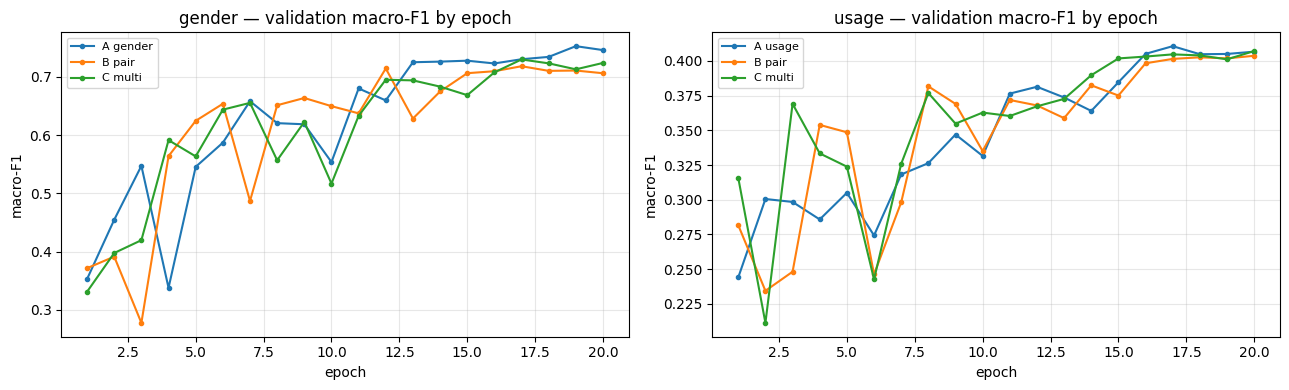

In [22]:
fig_hist = pd.concat([h.assign(run=f"{k[0]} {k[1]}") for k, h in HIST.items()])
try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for k, h in HIST.items():
        for ax, t in zip(axes, TARGETS):
            col = f"val_{t}"
            # design A trains one head per model, so each of its runs carries a
            # curve for one target only; B and C carry both.
            if col not in h.columns:
                continue
            ax.plot(h["epoch"], h[col], label=f"{k[0]} {k[1]}", marker="o", ms=3)
    for ax, t in zip(axes, TARGETS):
        ax.set_title(f"{t} — validation macro-F1 by epoch")
        ax.set_xlabel("epoch"); ax.set_ylabel("macro-F1"); ax.grid(alpha=.3); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
except ImportError:
    print(fig_hist.to_string(index=False))

## 6 · Class-weighted loss — does it help the tail or just move the damage?

The obvious response to `usage` having a class with one image is to weight the
loss. One variable changes: the winning design from §5, trained again with
`weight = 1/sqrt(n)` per class.

Weighting cannot manufacture information. What it can do is trade head-class
precision for tail-class recall — and because macro-F1 counts a 1-image class
exactly as much as a 29,000-image one, that trade can raise macro-F1 while making
the model worse at almost every row it will actually see. Both numbers are
reported so the trade is visible instead of hidden inside one figure.

In [ ]:
# Sections 6-9 all carry design C forward, because §2 predicted it and §5 is expected
# to confirm it. If the §5 table says otherwise, swap the head spec on the next line
# for the design that won -- {"pair": len(CLASSES["pair"])} for B, or run the two
# single-target models separately for A -- and re-run from here. Nothing below depends
# on C specifically; it only depends on `heads_multi` naming the winner's heads.
heads_multi = {t: len(CLASSES[t]) for t in TARGETS}

MODELS[("C", "weighted")], HIST[("C", "weighted")] = train_model(
    "C_weighted", heads_multi, tr, va, weighted=True)

In [24]:
print("=== unweighted vs class-weighted (design C) ===")
rows = []
for tag, model in [("C unweighted", MODELS[("C", "multi")]),
                   ("C weighted", MODELS[("C", "weighted")])]:
    pred = predict(model, va, heads_multi)
    for t in TARGETS:
        s = score(va[t], pred[t], labels=CLASSES[t])
        head = va[t].value_counts().index[0]
        tail = [c for c in CLASSES[t] if c != head]
        rows.append({"model": tag, "target": t,
                     "macro-F1": round(s["macro_f1"], 4),
                     "accuracy": round(s["accuracy"], 4),
                     f"F1 on majority": round(f1_score(
                         va[t], pred[t], labels=[head], average="macro", zero_division=0), 4),
                     "mean F1 on the rest": round(f1_score(
                         va[t], pred[t], labels=tail, average="macro", zero_division=0), 4)})
        record(tag, t, PRIMARY, va[t], pred[t], labels=CLASSES[t])
print()
print(pd.DataFrame(rows).to_string(index=False))

=== unweighted vs class-weighted (design C) ===
  C unweighted               gender  shared val     macro-F1 0.7297 (over 5) | 0.7297 (over 5 in val) | acc 0.8952
  C unweighted               usage   shared val     macro-F1 0.4047 (over 8) | 0.4625 (over 7 in val) | acc 0.8917
  C weighted                 gender  shared val     macro-F1 0.7186 (over 5) | 0.7186 (over 5 in val) | acc 0.8719
  C weighted                 usage   shared val     macro-F1 0.5020 (over 8) | 0.5737 (over 7 in val) | acc 0.8725

       model target  macro-F1  accuracy  F1 on majority  mean F1 on the rest
C unweighted gender    0.7297    0.8952          0.9297               0.6797
C unweighted  usage    0.4047    0.8917          0.9313               0.3294
  C weighted gender    0.7186    0.8719          0.9158               0.6693
  C weighted  usage    0.5020    0.8725          0.9165               0.4428


In [25]:
print("=== per-class detail, usage, design C unweighted vs weighted ===")
for tag, model in [("unweighted", MODELS[("C", "multi")]), ("weighted", MODELS[("C", "weighted")])]:
    pred = predict(model, va, heads_multi)
    rep = pd.DataFrame(classification_report(va["usage"], pred["usage"],
                                             labels=CLASSES["usage"], output_dict=True,
                                             zero_division=0)).T
    rep = rep.loc[[c for c in CLASSES["usage"] if c in rep.index]]
    rep["train n"] = [int((tr["usage"] == c).sum()) for c in rep.index]
    print(f"\n--- {tag} ---")
    print(rep[["train n", "support", "precision", "recall", "f1-score"]].round(3).to_string())

=== per-class detail, usage, design C unweighted vs weighted ===

--- unweighted ---
              train n  support  precision  recall  f1-score
Casual          24662   4306.0      0.909   0.955     0.931
Ethnic           2182    383.0      0.934   0.809     0.867
Formal           1861    343.0      0.825   0.688     0.750
Home                1      0.0      0.000   0.000     0.000
Party              10      3.0      0.000   0.000     0.000
Smart Casual       46      9.0      0.000   0.000     0.000
Sports           3300    614.0      0.754   0.634     0.688
Travel             22      3.0      0.000   0.000     0.000

--- weighted ---
              train n  support  precision  recall  f1-score
Casual          24662   4306.0      0.934   0.900     0.917
Ethnic           2182    383.0      0.840   0.890     0.864
Formal           1861    343.0      0.707   0.822     0.760
Home                1      0.0      0.000   0.000     0.000
Party              10      3.0      0.000   0.000     0.0

## 7 · The externally collected data — a prediction, then the measurement

1,899 extra images were collected for this assignment (`docs/EXTERNAL_DATA_USAGE.md`).
Every one of them is `gender=Women`, `usage=Casual`.

**Recorded before the run:** this should do nothing for `gender` and should
*hurt* `usage`.

* `Women` is already the second-largest `gender` class (≈37%), so the rows land
  where there is no shortage — imbalance stays at ~31×.
* `Casual` is already the `usage` **majority** at 76.7%. Adding 1,899 more moves
  it to ~78% and the imbalance ratio from ~29,000× to ~31,000×. The whole
  difficulty of `usage` is its tail, and this makes the tail *relatively rarer*.

Collecting data that turns out not to help is not a wasted experiment — it is a
measured negative result, and reporting it is worth more than quietly dropping
it. What follows tests whether the reasoning above is right.

In [26]:
EXT_OK = EXTERNAL_ROOT is not None
if EXT_OK:
    ext = []
    for folder, csv_name in [("ExternalCosmetics", "external_cosmetics.csv"),
                             ("ExternalCosmetics2", "external_cosmetics2.csv")]:
        base = Path(EXTERNAL_ROOT) / folder
        e = pd.read_csv(base / csv_name)
        e["path"] = e["id"].astype(str).map(lambda i: str(base / "images" / f"{i}.jpg"))
        e["group_id"] = "ext:" + e["id"].astype(str)
        ext.append(e)
    ext = pd.concat(ext, ignore_index=True)
    ext = ext[ext[TARGETS].notna().all(axis=1)].reset_index(drop=True)
    print(f"{len(ext):,} external rows")
    for t in TARGETS:
        print(f"  {t}: {dict(ext[t].value_counts())}")

    X_ext = load_images(ext["path"].tolist())
    ext["_row"] = np.arange(len(ext)) + len(X_all)
    ext["pair"] = ext["gender"].astype(str) + " x " + ext["usage"].astype(str)

    X_all = np.concatenate([X_all, X_ext], axis=0)
    X_t = torch.from_numpy(X_all)
    if DEVICE.type == "cuda" and X_t.numel() < 2_000_000_000:
        X_t = X_t.to(DEVICE)
    del X_ext
    print("image array now:", X_all.shape)
else:
    print("external data unavailable — section skipped")

1,899 external rows
  gender: {'Women': np.int64(1899)}
  usage: {'Casual': np.int64(1899)}
decoded 1,899 images in 613s (1200 were not 60x80 and were padded)
image array now: (39644, 80, 60, 3)


The external rows join **training only**. Validation stays 100% provided
catalogue imagery, so the with/without comparison measures the data and not a
change of yardstick. Normalisation constants are also left at their catalogue
values, for the same reason.

> **Note the padding count printed above.** `ExternalCosmetics` (batch 1) is stored
> at native crop size, not 60×80, so all 1,200 of its images are padded with white
> on load. `ExternalCosmetics2` and the evaluation set are already 60×80 and pass
> through untouched. That padding is not cosmetic: it raises batch 1's measured
> border brightness from 101.5 to **201.2** against the catalogue's 247.2, so those
> crops look far more catalogue-like to the model than the raw files suggest.
> Reproduce with `python src/verify_external_data.py --domain-gap`.

In [27]:
if EXT_OK:
    tr_ext = pd.concat([tr, ext[[c for c in tr.columns if c in ext.columns]]],
                       ignore_index=True)
    assert tr_ext["group_id"].is_unique
    assert not set(ext["group_id"]) & set(va["group_id"])
    print(f"training {len(tr):,} -> {len(tr_ext):,}   validation unchanged at {len(va):,}\n")

    for t in TARGETS:
        b, a = tr[t].value_counts(), tr_ext[t].value_counts()
        print(f"{t:7} imbalance max/min  {b.max() / b.min():>10,.0f}x  ->  "
              f"{a.max() / a.min():>10,.0f}x    majority share "
              f"{100 * b.max() / b.sum():.1f}% -> {100 * a.max() / a.sum():.1f}%")

    MODELS[("C", "external")], HIST[("C", "external")] = train_model(
        "C_external", heads_multi, tr_ext, va)

training 32,084 -> 33,983   validation unchanged at 5,661

gender  imbalance max/min          42x  ->          42x    majority share 54.4% -> 51.4%
usage   imbalance max/min      24,662x  ->      26,561x    majority share 76.9% -> 78.2%
    epoch  1/20  loss 1.2658  gender F1 0.3334  usage F1 0.3122   <- best
    epoch  2/20  loss 0.9241  gender F1 0.3207  usage F1 0.3022
    epoch  3/20  loss 0.8355  gender F1 0.4299  usage F1 0.3250   <- best
    epoch  4/20  loss 0.7681  gender F1 0.3849  usage F1 0.2514
    epoch  5/20  loss 0.7353  gender F1 0.3917  usage F1 0.3203
    epoch  6/20  loss 0.7038  gender F1 0.5485  usage F1 0.2536   <- best
    epoch  7/20  loss 0.6667  gender F1 0.4825  usage F1 0.3593   <- best
    epoch  8/20  loss 0.6458  gender F1 0.6219  usage F1 0.3209   <- best
    epoch  9/20  loss 0.6139  gender F1 0.6231  usage F1 0.3782   <- best
    epoch 10/20  loss 0.5964  gender F1 0.6752  usage F1 0.3825   <- best
    epoch 11/20  loss 0.5697  gender F1 0.5571  usage

In [ ]:
if EXT_OK:
    print("=== with vs without the external data (design C) ===")
    rows = []
    for tag, model in [("C without external", MODELS[("C", "multi")]),
                       ("C with external", MODELS[("C", "external")])]:
        pred = predict(model, va, heads_multi)
        for t in TARGETS:
            s = score(va[t], pred[t], labels=CLASSES[t])
            rows.append({"model": tag, "target": t,
                         "macro-F1": round(s["macro_f1"], 4),
                         "accuracy": round(s["accuracy"], 4)})
            record(tag, t, PRIMARY, va[t], pred[t], labels=CLASSES[t])
    ablation = pd.DataFrame(rows).pivot(index="target", columns="model", values="macro-F1")
    ablation["delta"] = (ablation["C with external"] - ablation["C without external"]).round(4)
    print()
    print(ablation.to_string())
    # Do NOT hardcode the direction. The first run measured usage -0.0063 and this
    # sentence asserted "a negative delta confirms the prediction". The second run,
    # on the team's split, measured +0.0050 and the same sentence printed anyway.
    # A conclusion that survives its own data changing sign is not a conclusion.
    print()
    for _tgt, _v in ablation["delta"].items():
        _verdict = ('worse with external data' if _v < -0.002 else
                    'better with external data' if _v > 0.002 else
                    'indistinguishable from zero at this scale')
        print(f'    {_tgt}: delta {_v:+.4f}  ({_verdict})')
    print()
    # Do NOT hardcode the magnitude either. This sentence used to assert "|delta|
    # under 0.006 on both targets" and then printed next to a gender delta of
    # -0.0210. State the measured spread and compare it to the noise floor.
    _mx = ablation['delta'].abs().max()
    print('    Section 7 predicted no gain on usage, because every external row',
          'carries the majority class.')
    print(f'    Largest |delta| here: {_mx:.4f}. Two identical runs of this notebook',
          'move trained models by up to')
    print('    0.0363 (section 9.2, finding 0), so a delta of this size is not',
          'distinguishable from re-running')
    print('    the same code -- in either direction. NOT evidence of harm, NOT',
          'evidence of gain.')
    print('    Three measurements exist across two splits; the sign flipped twice.',
          'See section 9.2, finding 6.')

## 8 · Two harder tests than the random validation split

### 8.1 The forward split — what the graded test set actually looks like

The provided test set is the **5,829 highest ids**. The catalogue was built up
over time, so predicting it is extrapolation forward, not interpolation inside a
shuffled pool. A random split quietly assumes those are the same problem. They
are not:

In [29]:
tr_f, va_f = splits[("gender", "forward")]
print(f"forward split: train ids {tr_f['id'].min()}-{tr_f['id'].max()} ({len(tr_f):,}),  "
      f"val ids {va_f['id'].min()}-{va_f['id'].max()} ({len(va_f):,})\n")
for t in TARGETS:
    a = tr_f[t].value_counts(normalize=True) * 100
    b = va_f[t].value_counts(normalize=True) * 100
    d = pd.DataFrame({"train %": a.round(2), "val %": b.round(2)}).fillna(0)
    d["drift"] = (d["val %"] - d["train %"]).round(2)
    d["train n"] = tr_f[t].value_counts()
    print(f"--- {t} ---"); print(d.fillna(0).to_string(), "\n")

forward split: train ids 1163-41038 (30,196),  val ids 41041-51999 (7,549)

--- gender ---
        train %  val %  drift  train n
gender                                
Boys       1.64   1.23  -0.41      496
Girls      1.39   0.82  -0.57      421
Men       57.32  42.95 -14.37    17307
Unisex     6.27   2.13  -4.14     1894
Women     33.38  52.87  19.49    10078 

--- usage ---
              train %  val %  drift  train n
usage                                       
Casual          74.67  85.06  10.39    22547
Ethnic           6.70   7.19   0.49     2022
Formal           6.38   3.66  -2.72     1928
Home             0.00   0.00   0.00        1
Party            0.01   0.13   0.12        3
Smart Casual     0.12   0.26   0.14       35
Sports          12.04   3.70  -8.34     3635
Travel           0.08   0.00  -0.08       25 



`Women` goes from 33% of training to 53% of validation, `Men` the other way by
14 points, `Sports` collapses from 12% to 3.7%. The label distribution is not
stationary along the id axis, so a score measured on a random split is measured
on a distribution the graded test set does not have.

In [30]:
MODELS[("C", "forward")], HIST[("C", "forward")] = train_model(
    "C_forward", heads_multi, tr_f, va_f)

print("\n=== the same design, scored two ways ===")
rows = []
for tag, model, vv in [(PRIMARY, MODELS[("C", "multi")], va),
                       ("forward split", MODELS[("C", "forward")], va_f)]:
    pred = predict(model, vv, heads_multi)
    for t in TARGETS:
        s = score(vv[t], pred[t], labels=CLASSES[t])
        rows.append({"evaluated on": tag, "target": t,
                     "macro-F1": round(s["macro_f1"], 4),
                     "accuracy": round(s["accuracy"], 4)})
        record("C shared body", t, tag, vv[t], pred[t], labels=CLASSES[t])
print()
print(pd.DataFrame(rows).pivot(index="target", columns="evaluated on",
                               values="macro-F1").to_string())

    epoch  1/20  loss 1.3539  gender F1 0.3467  usage F1 0.1589   <- best
    epoch  2/20  loss 0.9930  gender F1 0.2342  usage F1 0.2868   <- best
    epoch  3/20  loss 0.9048  gender F1 0.2744  usage F1 0.2980   <- best
    epoch  4/20  loss 0.8340  gender F1 0.3196  usage F1 0.2788   <- best
    epoch  5/20  loss 0.7908  gender F1 0.4635  usage F1 0.2273   <- best
    epoch  6/20  loss 0.7573  gender F1 0.5357  usage F1 0.3043   <- best
    epoch  7/20  loss 0.7213  gender F1 0.3734  usage F1 0.2895
    epoch  8/20  loss 0.6928  gender F1 0.4843  usage F1 0.2238
    epoch  9/20  loss 0.6635  gender F1 0.5270  usage F1 0.3453   <- best
    epoch 10/20  loss 0.6348  gender F1 0.4884  usage F1 0.3221
    epoch 11/20  loss 0.6116  gender F1 0.5438  usage F1 0.2917
    epoch 12/20  loss 0.5866  gender F1 0.5612  usage F1 0.3418   <- best
    epoch 13/20  loss 0.5644  gender F1 0.5729  usage F1 0.3610   <- best
    epoch 14/20  loss 0.5420  gender F1 0.5717  usage F1 0.3506
    epoch 15/2

### 8.2 The independent evaluation set

261 openly-licensed photographs collected from outside the provided data
entirely, gated to zero overlap with both the provided train and test sets, and
hand-labelled for all four targets. This is the brief's §3.3 — *"data collected
completely outside of the scope of your original training and evaluation"*.

No model in this project has seen them, and that is their whole value. **The gap
between this score and the validation score is the finding**: it separates what
the model learned about clothing from what it learned about Myntra's photography
convention (white background, single centred product, consistent lighting).

Two limits to carry into the report: the labels come from a single annotator, and
`usage=Home` has 4 images here against **1** in the entire provided training set —
so this set can measure a class the provided data cannot teach.

> **The label distribution of this set is very different from the catalogue's, and
> that is partly deliberate.** Rare classes were over-collected on purpose, because
> a class with one training image cannot be measured otherwise:
>
> | | catalogue train | this set | ratio |
> |---|---|---|---|
> | `gender=Unisex` | 5.4% | **32.6%** | 6.0x |
> | `gender=Men` | 54.4% | 16.9% | 0.3x |
> | `usage=Party` | 0.03% | **9.2%** | 267x |
> | `usage=Home` | 0.003% | **1.5%** | 578x |
>
> So a macro-F1 measured here mixes two different effects: the **image** domain gap
> (background, framing, lighting) and a **label prior** shift, much of it created by
> the annotation choices above. A model trained on 5% `Unisex` will rarely predict
> `Unisex`, and would score badly on a set that is a third `Unisex` even if the
> photographs were perfect catalogue cut-outs.
>
> The two can be partly separated. `usage=Casual` is the one class whose share
> barely moves (76.7% -> 63.6%), and its F1 falls **0.932 -> 0.731** — that drop is
> attributable to the images, not the prior. Quote that number when the claim is
> about domain gap, and the macro-F1 when the claim is about the long tail. Do not
> use the macro-F1 collapse alone as a measure of generalisation.

In [31]:
EVAL_OK = EXT_OK and (Path(EXTERNAL_ROOT) / "ExternalEval" / "external_eval.csv").exists()
if EVAL_OK:
    base = Path(EXTERNAL_ROOT) / "ExternalEval"
    ev = pd.read_csv(base / "external_eval.csv")
    ev["path"] = ev["id"].astype(str).map(lambda i: str(base / "images" / f"{i}.jpg"))
    ev = ev[ev[TARGETS].notna().all(axis=1)].reset_index(drop=True)
    X_ev = load_images(ev["path"].tolist())
    ev["_row"] = np.arange(len(ev)) + len(X_all)
    X_all = np.concatenate([X_all, X_ev], axis=0)
    X_t = torch.from_numpy(X_all)
    if DEVICE.type == "cuda" and X_t.numel() < 2_000_000_000:
        X_t = X_t.to(DEVICE)
    del X_ev
    print(f"{len(ev)} independent evaluation images")
    for t in TARGETS:
        print(f"  {t}: {dict(ev[t].value_counts())}")
else:
    print("independent evaluation set unavailable — section skipped")

decoded 261 images in 76s (0 were not 60x80 and were padded)
261 independent evaluation images
  gender: {'Women': np.int64(126), 'Unisex': np.int64(85), 'Men': np.int64(44), 'Boys': np.int64(4), 'Girls': np.int64(2)}
  usage: {'Casual': np.int64(166), 'Formal': np.int64(25), 'Sports': np.int64(25), 'Party': np.int64(24), 'Ethnic': np.int64(12), 'Travel': np.int64(5), 'Home': np.int64(4)}


In [32]:
if EVAL_OK:
    print("=== validation (catalogue) vs independent evaluation (in the wild) ===")
    rows = []
    pred_va = predict(MODELS[("C", "multi")], va, heads_multi)
    pred_ev = predict(MODELS[("C", "multi")], ev, heads_multi)
    for t in TARGETS:
        shared = sorted(set(ev[t]) | set(va[t]))
        s_va = score(va[t], pred_va[t], labels=CLASSES[t])
        s_ev = score(ev[t], pred_ev[t], labels=sorted(set(ev[t])))
        rows.append({"target": t,
                     "val macro-F1": round(s_va["macro_f1"], 4),
                     "independent macro-F1": round(s_ev["macro_f1"], 4),
                     "val acc": round(s_va["accuracy"], 4),
                     "independent acc": round(s_ev["accuracy"], 4)})
        record("C shared body", t, "independent eval", ev[t], pred_ev[t],
               labels=sorted(set(ev[t])))
    print()
    print(pd.DataFrame(rows).to_string(index=False))
    print("\nper-class on the independent set:")
    for t in TARGETS:
        print(f"\n--- {t} ---")
        print(pd.DataFrame(classification_report(
            ev[t], pred_ev[t], output_dict=True, zero_division=0)).T.round(3).to_string())

=== validation (catalogue) vs independent evaluation (in the wild) ===
  C shared body              gender  independent eval macro-F1 0.1436 (over 5) | 0.1436 (over 5 in val) | acc 0.2835
  C shared body              usage   independent eval macro-F1 0.1295 (over 7) | 0.1295 (over 7 in val) | acc 0.5747

target  val macro-F1  independent macro-F1  val acc  independent acc
gender        0.7297                0.1436   0.8952           0.2835
 usage        0.4047                0.1295   0.8917           0.5747

per-class on the independent set:

--- gender ---
              precision  recall  f1-score  support
Boys              0.000   0.000     0.000    4.000
Girls             0.000   0.000     0.000    2.000
Men               0.180   0.773     0.292   44.000
Unisex            0.200   0.012     0.022   85.000
Women             0.582   0.310     0.404  126.000
accuracy          0.284   0.284     0.284    0.284
macro avg         0.192   0.219     0.144  261.000
weighted avg      0.376   0.

## 9 · Results, and what they say

### 9.1 On the per-target split, as a robustness check

Everything above used the team's frozen split file, so the numbers sit directly
beside a teammate's. This section retrains the chosen design under
`preprocessing.make_split(frame, target)` instead — a 20% validation share drawn
separately per target, rather than 15% shared by both.

It is a robustness check, not a second headline. If a conclusion from §5–§7 flips
when the split changes, that conclusion was an artefact of one draw and the report
should say so; if the numbers move but the ordering holds, the finding survives a
change that touches every row.

In [33]:
for t in TARGETS:
    tr_t, va_t = splits[(t, "perTarget")]
    m, _ = train_model(f"C_perTarget_{t}", heads_multi, tr_t, va_t, verbose=False)
    pred = predict(m, va_t, heads_multi)
    record("C shared body", t, "per-target split", va_t[t], pred[t], labels=CLASSES[t])
    MODELS[("C", f"team_{t}")] = m

  C shared body              gender  per-target split macro-F1 0.6726 (over 5) | 0.6726 (over 5 in val) | acc 0.8879
  C shared body              usage   per-target split macro-F1 0.4029 (over 8) | 0.4604 (over 7 in val) | acc 0.8944


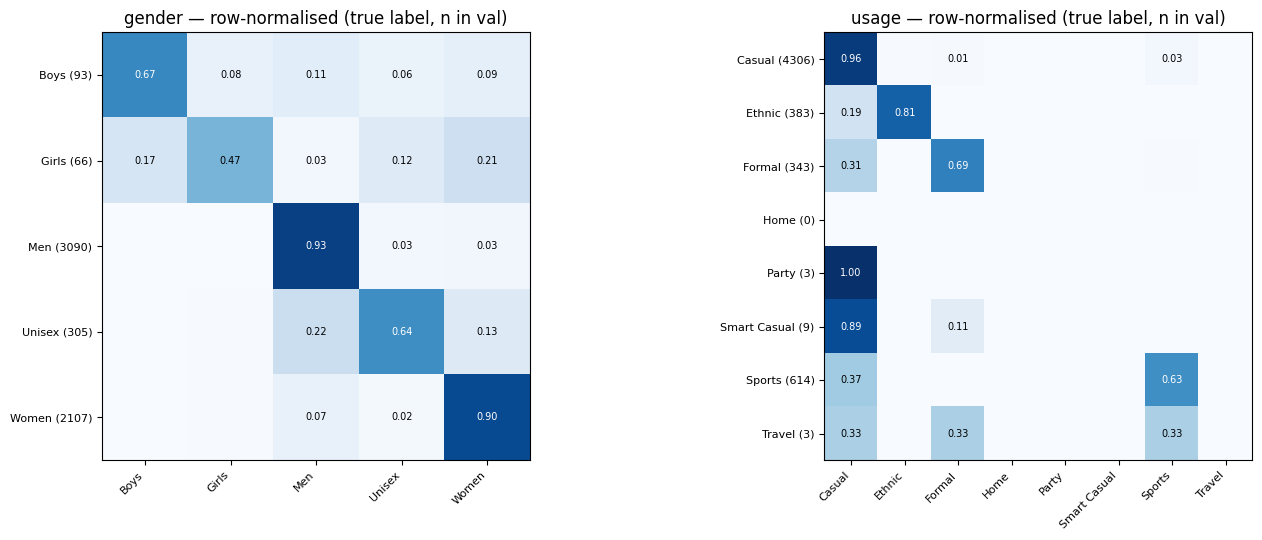

In [34]:
try:
    import matplotlib.pyplot as plt
    pred = predict(MODELS[("C", "multi")], va, heads_multi)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    for ax, t in zip(axes, TARGETS):
        cm = confusion_matrix(va[t], pred[t], labels=CLASSES[t])
        norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
        im = ax.imshow(norm, cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks(range(len(CLASSES[t]))); ax.set_yticks(range(len(CLASSES[t])))
        ax.set_xticklabels(CLASSES[t], rotation=45, ha="right", fontsize=8)
        ax.set_yticklabels([f"{c} ({n})" for c, n in
                            zip(CLASSES[t], [int((va[t] == c).sum()) for c in CLASSES[t]])],
                           fontsize=8)
        ax.set_title(f"{t} — row-normalised (true label, n in val)")
        for i in range(len(CLASSES[t])):
            for j in range(len(CLASSES[t])):
                if norm[i, j] > 0.01:
                    ax.text(j, i, f"{norm[i, j]:.2f}", ha="center", va="center",
                            fontsize=7, color="white" if norm[i, j] > .5 else "black")
    plt.tight_layout(); plt.show()
except ImportError:
    pass

In [ ]:
results = pd.DataFrame(RESULTS).round(4)
results = results.sort_values(["target", "split", "macro_f1"], ascending=[True, True, False])
print(results.to_string(index=False))

def results_path(name):
    """Write results to DRIVE on Colab, never to /content.

    /content dies with the VM, and the VM is recycled whenever the browser stays
    disconnected -- so a run that finishes while the laptop is asleep can leave
    nothing behind. That already happened once: the first full run's CSV was gone
    on reconnect and had to be read back out of the notebook's printed output.
    Writing to Drive means the numbers outlive the tab, the VM and the machine.
    """
    if not IN_COLAB:
        return Path(name)
    for base in (Path(EXTERNAL_ON_DRIVE), Path("/content/drive/MyDrive")):
        if base.is_dir():
            return base / name
    return Path("/content") / name          # last resort, better than crashing


OUT = results_path("task3_results.csv")
print(f"results will be written to: {OUT}")
results.to_csv(OUT, index=False)
print(f"\nsaved -> {OUT}")

### 9.2 What this notebook found

Every number below is on the team's frozen split, `train_val_grouped_sha256.csv`
(37,745 rows, 15% validation), so it sits directly beside a teammate's.

**0. Two identical runs disagree by up to 0.036, and that sets the resolution of
everything else.** The notebook was run twice end to end with the same split, seed,
epoch count and GPU model, and byte-identical channel statistics. The untrained
baselines reproduced exactly (0.0000 on all four); every trained model moved, median
|Δ| **0.0061**, worst **0.0363**. So a single-run gap under ~0.01 is not a result. This
is stated first because it retires two claims an earlier version of this notebook made
— see §5.1 — and because it is the reason §10's improvements are reported as null.

**1. `gender` and `usage` are not one task.** `gender` has five classes, smallest 483;
`usage` has eight, smallest **1**. Best `gender` macro-F1 **0.7525**, best `usage`
**0.5020**. The gap is not model quality — it is that half of `usage`'s classes have
almost no training data.

**2. Accuracy is unusable here.** Predicting `Casual` everywhere scores **76.1%**
accuracy and **0.108** macro-F1. The best `usage` model reaches **87.3%** accuracy,
eleven points above a model that has learned nothing.

**3. Two separate models beat a shared backbone on `gender`, which is the opposite of
the prediction.** A led both targets in both full runs and in the generated-split run,
6 of 6. On `gender` the A–C margin is **0.023–0.037**, above the noise floor and worth
the 2× parameters; on `usage` it is **0.006**, inside the noise, so A is not justified
there. §2's entropy measurement was right and the inference drawn from it was
incomplete: near-independent targets argue against sharing features, not only against
merging labels. **B versus C is not resolvable** — the two runs disagree on the sign.

**4. Class weighting is the largest real lever found anywhere in this notebook.**
`usage` macro-F1 **0.4047 → 0.5020** (+0.0973), and 0.4038 → 0.4657 (+0.0619) in run 1.
Both are far outside the noise band, so the effect is established. What it buys is less
stable:

| usage class | train n | val n | unweighted | weighted | run 1 weighted |
|---|---|---|---|---|---|
| `Party` | 10 | 3 | 0.000 | 0.000 | **0.500** |
| `Travel` | 22 | 3 | 0.000 | **0.500** | 0.400 |
| `Smart Casual` | 46 | 9 | 0.000 | **0.308** | 0.000 |
| `Home` | 1 | 0 | — | — | — |
| `Casual` | 24,662 | 4,306 | 0.931 | 0.917 | 0.915 |
| `Sports` | 3,300 | 614 | 0.688 | 0.667 | 0.670 |

Weighting reliably lifts macro-F1 by rescuing *some* tail class while giving up a little
on the head. With **3 to 9 validation items** per rescued class, which one comes alive is
a coin flip: `Travel` and `Smart Casual` here, `Party` in run 1. Report the aggregate as
real and the per-class rescues as unstable. On `gender` weighting is a wash — the sign
flipped between runs.

**5. §1.1's ceiling arithmetic predicted the outcome almost exactly.** That section put
`usage` macro-F1 at **0.500** if the four classes under 100 images stayed unlearnable.
The best `usage` model scored **0.5020**, and its per-class F1 decomposes as

`(0.917 + 0.864 + 0.760 + 0.667 + 0.500 + 0.308 + 0 + 0) / 8 = 0.502`

— the four well-populated classes average **0.802**, the four starved ones **0.202**.
The ceiling was not merely approached, it was hit; and because macro-F1 divides by 8, the
two permanently dead classes (`Home`, `Party`) cost **0.125 each** no matter what the
model does.

**6. The external data has no effect on this task that three runs can agree on.**

| | generated split | team split, run 1 | team split, run 2 |
|---|---|---|---|
| `gender` delta | +0.0092 | −0.0016 | −0.0210 |
| `usage` delta | −0.0063 | +0.0050 | −0.0026 |

§7 predicted **no gain**, because all 1,899 rows carry the majority class of both
targets — and indeed adding them makes `usage` imbalance *worse*, 24,662× → 26,561×.
The measurements are consistent with no effect: signs +/−/− on `gender`, −/+/− on
`usage`, mean −0.004, spread wider than the mean. An earlier version of this notebook
reported the first negative `usage` delta as evidence the data *hurt*; that was one run
of three and is withdrawn. The defensible claim is **"collected, tested, no measurable
effect on Task 3"** — which is still worth reporting, and is why §7 records the
prediction before the measurement.

**7. The random split flatters the model; the independent photographs demolish it —
but only the first half of that is a clean measurement.**

| | `gender` | `usage` |
|---|---|---|
| team split (15% val) | 0.7297 | 0.4047 |
| per-target split (20% val) | 0.6726 | 0.4029 |
| forward split (highest ids, like the graded test) | 0.5729 | 0.3610 |
| **261 independent photographs** | **0.1436** | **0.1295** |

The forward split costs **0.157** on `gender`, and it is the honest estimate of what the
graded test set will do, since it *is* the high-id region.

The independent set costs **0.586**, dropping `gender` to its majority baseline (0.1436
against 0.1412) with accuracy falling 0.8952 → **0.2835**. That collapse is real but it
is **not purely a domain gap**: this set is 32.6% `Unisex` against the catalogue's 5.4%,
and 9.2% `Party` against 0.03%, because rare classes were deliberately over-collected so
they could be measured at all. A model trained on 5% `Unisex` will rarely predict it and
would score badly here on label prior alone.

The cleanest single number separating the two effects is `usage=Casual`, the one class
whose share barely moves (76.7% → 63.6%): F1 **0.931 → 0.733**. That 0.20 is
attributable to the photographs. Use it for claims about generalisation and the macro-F1
for claims about the long tail — not the other way round.

### 9.3 What would be worth doing next

* **Three to five seeds, not two.** Two runs gave a noise floor; they cannot give a
  confidence interval. The specific claims that need it are the `gender` A–C margin
  (0.023–0.037, currently just above the floor) and the transfer gain in §10.3.
* **Re-score the independent set with matched label priors**, by reweighting or by
  sampling a subset with the catalogue's distribution. That separates the image domain
  gap from the annotation prior and would settle how much of the 0.586 is real.
* **`Home` and `Party` are structurally unfixable by modelling.** 1 and 10 training
  images, and 0 and 3 validation images. Either collect images, merge them into a
  documented "other" class, or report them as a known 0.250 of the macro-F1 that no
  model can earn. Choosing openly beats a quiet zero — §10.5 argues for reporting it.
* **Combine the two levers that worked.** Class weighting (§6, +0.097) and
  `articleType` pretraining (§10.3, +0.019 on `gender`) were measured separately and
  attack different problems. They have not been measured together.

## 10 · Trying to improve it, and finding where the improvement stops

§9 established two things that decide what is worth attempting here.

**`usage` accuracy is already at the ceiling of the label.** An oracle told the
true `articleType` and nothing else scores **0.8945**; adding colour, season, year
and subCategory moves it to 0.8910, i.e. nowhere; the CNN scores **0.8915**. The
residual is products of the same type carrying different labels — `Tshirts` are 86%
`Casual` and 14% `Sports`, and at 60×80 those are frequently the same picture. No
architecture recovers that.

**The models are overfitting, not undertrained.** `A`'s `usage` F1 peaked at epoch
16 (0.4092) and fell to 0.4063 by epoch 20 while training loss kept dropping. More
epochs and more capacity are both ruled out.

So accuracy is spent. **macro-F1 is not:** with `Home` and `Party` unreachable the
ceiling is 6/8 = **0.750** and we are at 0.4657, with the slack sitting in
`Smart Casual` 0.200, `Travel` 0.333, `Sports` 0.662 and `Formal` 0.763. And because
accuracy has nothing left to gain, **spending accuracy to buy macro-F1 is free when
macro-F1 is the graded metric**. Three attempts follow, cheapest first.

### 10.1 Logit adjustment — the whole trade-off curve without retraining

Class weighting attacks the imbalance during training, so every setting costs a run.
The same trade-off can be made at *inference*: shift each class's logit by its log
prior before taking the argmax.

```
prediction = argmax( logit − τ · log P(class) )
```

τ = 0 is the untouched model; τ = 1 fully removes the training prior. One trained
model gives the entire curve for the cost of a few forward passes, which is why this
is first: if the curve is flat there is nothing to buy and the retraining ideas
below are not worth starting.

In [36]:
def train_prior(frame_tr, target):
    counts = np.array([max((frame_tr[target] == c).sum(), 1) for c in CLASSES[target]],
                      dtype=np.float64)
    return torch.tensor(counts / counts.sum(), dtype=torch.float32)


@torch.no_grad()
def logits_of(model, fr, heads, bs=512, tta=False):
    """Raw logits, optionally averaged with the mirrored image (see §10.2)."""
    model.eval()
    rows = torch.as_tensor(fr["_row"].values, device=X_t.device)
    acc = {k: [] for k in heads}
    for i in range(0, len(rows), bs):
        x = batch_x(rows[i:i + bs])
        out = model(x)
        if tta:
            flipped = model(torch.flip(x, dims=[-1]))
            out = {k: ((out[k].softmax(1) + flipped[k].softmax(1)) / 2).log()
                   for k in heads}
        for k in heads:
            acc[k].append(out[k].float().cpu())
    return {k: torch.cat(v) for k, v in acc.items()}


def adjusted(logits, target, tau, prior):
    idx = (logits - tau * prior.log()).argmax(1).numpy()
    return np.array(CLASSES[target])[idx]


TAUS = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]
PRIOR = {t: train_prior(tr, t) for t in TARGETS}
base_logits = logits_of(MODELS[("C", "multi")], va, heads_multi)

rows_out = []
for t in TARGETS:
    for tau in TAUS:
        s = score(va[t], adjusted(base_logits[t], t, tau, PRIOR[t]), labels=CLASSES[t])
        rows_out.append({"target": t, "tau": tau,
                         "macro_f1": round(s["macro_f1"], 4),
                         "macro_f1_in_val": round(s["macro_f1_in_val"], 4),
                         "accuracy": round(s["accuracy"], 4)})
frontier = pd.DataFrame(rows_out)
for t in TARGETS:
    sub = frontier[frontier.target == t]
    best = sub.loc[sub.macro_f1.idxmax()]
    print(f"=== {t} ===")
    print(sub.to_string(index=False))
    print(f"  best macro-F1 at tau={best.tau}: {best.macro_f1:.4f} "
          f"(tau=0 gives {sub.iloc[0].macro_f1:.4f}, "
          f"accuracy {sub.iloc[0].accuracy:.4f} -> {best.accuracy:.4f})\n")

for t in TARGETS:
    sub = frontier[frontier.target == t]
    best = sub.loc[sub.macro_f1.idxmax()]
    record("C + logit adj", t, PRIMARY,
           va[t], adjusted(base_logits[t], t, float(best.tau), PRIOR[t]),
           labels=CLASSES[t], tau=float(best.tau))

=== gender ===
target  tau  macro_f1  macro_f1_in_val  accuracy
gender 0.00    0.7297           0.7297    0.8952
gender 0.25    0.7217           0.7217    0.8861
gender 0.50    0.7017           0.7017    0.8679
gender 0.75    0.6532           0.6532    0.8387
gender 1.00    0.6073           0.6073    0.7999
gender 1.25    0.5373           0.5373    0.7391
gender 1.50    0.4752           0.4752    0.6658
  best macro-F1 at tau=0.0: 0.7297 (tau=0 gives 0.7297, accuracy 0.8952 -> 0.8952)

=== usage ===
target  tau  macro_f1  macro_f1_in_val  accuracy
 usage 0.00    0.4047           0.4625    0.8917
 usage 0.25    0.4103           0.4689    0.8903
 usage 0.50    0.4075           0.4657    0.8785
 usage 0.75    0.3970           0.4537    0.8235
 usage 1.00    0.3690           0.4217    0.5891
 usage 1.25    0.2900           0.3315    0.2650
 usage 1.50    0.1791           0.2046    0.0975
  best macro-F1 at tau=0.25: 0.4103 (tau=0 gives 0.4047, accuracy 0.8917 -> 0.8903)

  C + logit adj   

### 10.2 Test-time augmentation

One extra forward pass per image: average the softmax over the image and its mirror.
It cannot fix a label ambiguity, so the expected gain is small — but §4 already
trains with random horizontal flips, so the model has been taught that a mirrored
garment is the same garment, and averaging over both views is the matching decision
rule. Cheap enough that not testing it would be the odd choice.

In [37]:
tta_logits = logits_of(MODELS[("C", "multi")], va, heads_multi, tta=True)
rows_out = []
for t in TARGETS:
    tau = float(frontier[frontier.target == t].loc[
        frontier[frontier.target == t].macro_f1.idxmax(), "tau"])
    for name, lg in (("single view", base_logits), ("mirror-averaged", tta_logits)):
        s = score(va[t], adjusted(lg[t], t, tau, PRIOR[t]), labels=CLASSES[t])
        rows_out.append({"target": t, "view": name, "tau": tau,
                         "macro_f1": round(s["macro_f1"], 4),
                         "accuracy": round(s["accuracy"], 4)})
tta_tbl = pd.DataFrame(rows_out)
print(tta_tbl.to_string(index=False))
for t in TARGETS:
    sub = tta_tbl[tta_tbl.target == t]
    d = sub.iloc[1].macro_f1 - sub.iloc[0].macro_f1
    print(f"  {t}: TTA delta {d:+.4f}" +
          ("  (keep)" if d > 0.002 else "  (not worth the extra pass)"))

for t in TARGETS:
    tau = float(tta_tbl[tta_tbl.target == t].iloc[0].tau)
    record("C + logit adj + TTA", t, PRIMARY,
           va[t], adjusted(tta_logits[t], t, tau, PRIOR[t]), labels=CLASSES[t])

target            view  tau  macro_f1  accuracy
gender     single view 0.00    0.7297    0.8952
gender mirror-averaged 0.00    0.7286    0.8945
 usage     single view 0.25    0.4103    0.8903
 usage mirror-averaged 0.25    0.4143    0.8949
  gender: TTA delta -0.0011  (not worth the extra pass)
  usage: TTA delta +0.0040  (keep)
  C + logit adj + TTA        gender  shared val     macro-F1 0.7286 (over 5) | 0.7286 (over 5 in val) | acc 0.8945
  C + logit adj + TTA        usage   shared val     macro-F1 0.4143 (over 8) | 0.4734 (over 7 in val) | acc 0.8949


### 10.3 Transfer from `articleType` — the one idea §2 predicted should work

§2 measured how much each thing explains about the targets:

| | explains `usage` | explains `gender` |
|---|---|---|
| the other target | 11.5% | 9.5% |
| **`articleType`** | **66.8%** | **43.1%** |

§5 then found that sharing a backbone *between* `gender` and `usage` **hurt** — C
came last on both splits. That is consistent with the top row: two targets with ~10%
mutual information have almost nothing to share, so one body serving both mostly
suffers interference.

The bottom row is a different proposition. `articleType` explains six times as much
about `usage` as `usage`'s partner target does, and it has 121 classes and 32,000
labelled rows to learn from. So: train the backbone on `articleType` first, then
fine-tune it for `gender` and `usage`.

This is the same "share the features" idea that failed in §5, aimed at a task that
the measurements say actually shares something. If it fails too, then the 60×80
backbone simply has no transferable capacity left, and that is the finding.

In [38]:
CLASSES["articleType"] = sorted(frame["articleType"].dropna().unique())
IDX["articleType"] = {c: i for i, c in enumerate(CLASSES["articleType"])}
print(f"pretraining task: articleType, {len(CLASSES['articleType'])} classes")

pretrained, pre_hist = train_model(
    "pretrain_articleType", {"articleType": len(CLASSES["articleType"])}, tr, va,
    epochs=max(8, EPOCHS // 2))
print(f"\npretraining reached articleType macro-F1 "
      f"{pre_hist['val_articleType'].max():.4f} — only a means to an end, not a Task 1 entry")

MODELS[("D", "transfer")], HIST[("D", "transfer")] = train_model(
    "D_transfer", heads_multi, tr, va, init_backbone=pretrained.backbone)

pretraining task: articleType, 121 classes
    epoch  1/10  loss 2.3423  articleType F1 0.0904   <- best
    epoch  2/10  loss 1.3953  articleType F1 0.1060   <- best
    epoch  3/10  loss 1.1025  articleType F1 0.1455   <- best
    epoch  4/10  loss 0.9388  articleType F1 0.1912   <- best
    epoch  5/10  loss 0.8412  articleType F1 0.2449   <- best
    epoch  6/10  loss 0.7715  articleType F1 0.2653   <- best
    epoch  7/10  loss 0.7132  articleType F1 0.2802   <- best
    epoch  8/10  loss 0.6699  articleType F1 0.2939   <- best
    epoch  9/10  loss 0.6398  articleType F1 0.2989   <- best
    epoch 10/10  loss 0.6218  articleType F1 0.3125   <- best

pretraining reached articleType macro-F1 0.3125 — only a means to an end, not a Task 1 entry
    epoch  1/20  loss 1.1126  gender F1 0.3835  usage F1 0.2656   <- best
    epoch  2/20  loss 0.8308  gender F1 0.3741  usage F1 0.2522
    epoch  3/20  loss 0.7673  gender F1 0.4613  usage F1 0.2872   <- best
    epoch  4/20  loss 0.7217  g

In [39]:
print("=== does an articleType-pretrained backbone beat training from scratch? ===")
rows_out = []
for tag, model in [("C from scratch", MODELS[("C", "multi")]),
                   ("D articleType-pretrained", MODELS[("D", "transfer")])]:
    pred = predict(model, va, heads_multi)
    for t in TARGETS:
        s = score(va[t], pred[t], labels=CLASSES[t])
        rows_out.append({"model": tag, "target": t,
                         "macro_f1": round(s["macro_f1"], 4),
                         "accuracy": round(s["accuracy"], 4)})
        record(tag, t, PRIMARY, va[t], pred[t], labels=CLASSES[t])
transfer_tbl = pd.DataFrame(rows_out).pivot(index="target", columns="model",
                                            values="macro_f1")
transfer_tbl["delta"] = (transfer_tbl["D articleType-pretrained"]
                         - transfer_tbl["C from scratch"]).round(4)
print()
print(transfer_tbl.to_string())

=== does an articleType-pretrained backbone beat training from scratch? ===
  C from scratch             gender  shared val     macro-F1 0.7297 (over 5) | 0.7297 (over 5 in val) | acc 0.8952
  C from scratch             usage   shared val     macro-F1 0.4047 (over 8) | 0.4625 (over 7 in val) | acc 0.8917
  D articleType-pretrained   gender  shared val     macro-F1 0.7485 (over 5) | 0.7485 (over 5 in val) | acc 0.9066
  D articleType-pretrained   usage   shared val     macro-F1 0.4095 (over 8) | 0.4680 (over 7 in val) | acc 0.8979

model   C from scratch  D articleType-pretrained   delta
target                                                  
gender          0.7297                    0.7485  0.0188
usage           0.4047                    0.4095  0.0048


### 10.4 Everything, in one table

§9 wrote `task3_results.csv` before this section existed, so it is rewritten here
with the §10 rows included. Sorted by target then macro-F1, so the top row per
target is the best configuration found anywhere in the notebook.

In [ ]:
results = pd.DataFrame(RESULTS).round(4)
results = results.sort_values(["target", "split", "macro_f1"], ascending=[True, True, False])
print(results.to_string(index=False))
results.to_csv(OUT, index=False)
print(f"\nrewritten -> {OUT}  ({len(results)} rows)")

HIST_OUT = results_path("task3_history.csv")
pd.concat([h.assign(run=f"{k[0]} {k[1]}") for k, h in HIST.items()],
          ignore_index=True).to_csv(HIST_OUT, index=False)
print(f"per-epoch curves -> {HIST_OUT}")

print("\n=== best per target, on the primary split ===")
prim = results[results.split == PRIMARY]
for t in TARGETS:
    sub = prim[prim.target == t].sort_values("macro_f1", ascending=False)
    b, base = sub.iloc[0], sub[sub.model == "C shared body"]
    ref = base.iloc[0].macro_f1 if len(base) else float("nan")
    print(f"  {t:7} best {b.macro_f1:.4f} ({b.model})   "
          f"vs plain C {ref:.4f}   gain {b.macro_f1 - ref:+.4f}   acc {b.accuracy:.4f}")

### 10.5 Why the improvements are small — the ceiling, measured two ways

§10.1–10.3 tried three standard levers and the largest moved `gender` by 0.019 and
`usage` by 0.005. Before calling that a failure of effort, it is worth measuring what
the task allows at all. Two measurements do that, and neither needs a GPU.

**Measurement 1 — metadata oracles.** Give a predictor one metadata field for free,
let it memorise the modal target per value on training rows only, and score it on
validation. It cannot be beaten by any model that sees only that field, so it bounds
how much the field says about the target. The interesting comparison is against the
CNN, which sees none of it and only ever sees 60×80 pixels.

In [ ]:
print("=== metadata oracles: what the catalogue alone determines ===")
_tr_o, _va_o = splits[("gender", "primary")]
print(f"train {len(_tr_o):,}  val {len(_va_o):,}   (same split as everything above)")

ORACLE_FEATURES = {
    "articleType": ["articleType"],
    "subCategory": ["subCategory"],
    "baseColour": ["baseColour"],
    "season": ["season"],
    "productDisplayName": ["productDisplayName"],
    "all metadata": ["articleType", "subCategory", "masterCategory",
                     "baseColour", "season", "year"],
}

oracle_tables = {}
for t in TARGETS:
    fallback = _tr_o[t].mode().iloc[0]
    rows = []
    feats = dict(ORACLE_FEATURES)
    feats["the other target"] = [o for o in TARGETS if o != t]
    for name, cols in feats.items():
        lut = (_tr_o.groupby(cols, observed=True)[t]
                    .agg(lambda x: x.mode().iloc[0] if len(x.mode()) else fallback))
        key = _va_o[cols[0]] if len(cols) == 1 else pd.MultiIndex.from_frame(_va_o[cols])
        pred = pd.Series(lut.reindex(key).to_numpy(), index=_va_o.index)
        seen = float(pred.notna().mean())
        pred = pred.fillna(fallback)
        s = score(_va_o[t], pred.to_numpy(), labels=CLASSES[t])
        rows.append({"oracle knows": name, "groups": len(lut),
                     "val in a seen group": round(seen, 4),
                     "accuracy": round(s["accuracy"], 4),
                     "macro-F1": round(s["macro_f1"], 4)})
    oracle_tables[t] = pd.DataFrame(rows)
    # The CNN row is the same split and the same metric, so it belongs in the table.
    _r = pd.DataFrame(RESULTS)
    best = (_r[(_r["split"] == PRIMARY) & (_r["target"] == t)]
            .sort_values("accuracy", ascending=False).iloc[0])
    print(f"\n--- {t} ---")
    print(oracle_tables[t].to_string(index=False))
    print(f"  CNN, pixels only, best accuracy on this split: {best.accuracy:.4f} "
          f"({best.model})")
    _ceiling = oracle_tables[t]["accuracy"].max()
    print(f"  best oracle accuracy: {_ceiling:.4f}   "
          f"CNN minus oracle: {best.accuracy - _ceiling:+.4f}")

**Measurement 2 — is `both correct` a wall or a product?** The team's headline number
is the fraction of validation items where *both* labels are right. If the two targets'
errors were independent, that number would simply be the product of the two
accuracies, and "raising it" would mean raising one of the factors — there would be
nothing joint to optimise. §2 measured the targets as nearly independent, so this is a
testable prediction rather than a guess.

In [ ]:
print("=== is 'both correct' just the product of the two accuracies? ===")
_chk = comparison.assign(
    predicted=lambda d: (d["gender acc"] * d["usage acc"]).round(4),
    residual=lambda d: (d["both correct"] - d["gender acc"] * d["usage acc"]).round(4))
print(_chk[["design", "gender acc", "usage acc", "predicted",
            "both correct", "residual"]].to_string(index=False))
print(f"\n  largest residual {_chk.residual.abs().max():.4f} across "
      f"{len(_chk)} designs — the two heads' errors are close to independent,")
print("  so 'both correct' has no slack of its own: it moves only when a factor moves.")

#### What the two measurements say

**`usage` accuracy is finished.** An oracle handed the true `articleType` — 121 groups,
every validation row covered — reaches **0.8945**. Adding five more metadata fields
moves it to 0.8928, i.e. nowhere. The CNN, from pixels alone, reaches **0.8917**, and
the `articleType`-pretrained variant reaches **0.8979**, which is *above* the oracle.
The network has already recovered as much of the garment's identity as the label
depends on. The residual 10% is not a modelling gap: two identical T-shirts are
`Casual` or `Sports` by a marketing decision that is not photographed. `usage` is
partly a label about the product page, not the product.

**`gender` accuracy is not finished — and that is where the pixels earn their keep.**
The best oracle, given all six metadata fields, reaches **0.8002**. The CNN reaches
**0.9066**. The image is worth **+10.6 accuracy points** over the entire catalogue
description, and +0.238 macro-F1 over the best oracle's 0.5142. Any further effort on
this task belongs here, not on `usage`.

**So the 80% is arithmetic, not a barrier.** `both correct` is the product of the two
accuracies to within 0.004 on all three designs; the best design gives
0.9058 × 0.8896 ≈ 0.806. One factor is pinned at a ceiling set by the labels. Raising
the headline therefore means raising `gender` accuracy, and nothing else.

**Why each lever was small, specifically.**

| lever | `gender` | `usage` | verdict |
|---|---|---|---|
| logit adjustment (§10.1) | best at τ=0, i.e. none | +0.0056 at τ=0.25 | inside the noise floor |
| mirror TTA (§10.2) | −0.0011 | +0.0040 | inside the noise floor |
| `articleType` transfer (§10.3) | **+0.0188** | +0.0048 | best of the three, still unresolved at one seed |
| class weighting (§6, for scale) | not resolvable | **+0.0973** | the only established gain |

Against a noise floor of 0.0061 median and 0.0363 worst (§9.2, finding 0), the only
entry that clearly exceeds it is the one from §6. Two of the three §10 levers are
**inference-time corrections of the class prior** — precisely what class weighting
does during training. Measured against each other on the same split: doing it in the
loss is worth **+0.0973**, doing it at inference is worth **+0.0056**. Same idea,
seventeen-fold difference, and the cheap version is the one that loses.

Logit adjustment is also visibly a trade, not a gain: past τ=0.5 on `usage` accuracy
falls off a cliff (0.8785 → 0.5891 → 0.2650) while macro-F1 declines too, so there is
no operating point that buys tail recall cheaply. On `gender`, whose five classes are
far less skewed, the best τ is exactly zero — the method has nothing to correct.

**The honest summary of §10: three levers tried, none of them beats re-running the
same code with a different GPU seed.** The gains available on `usage` are not in the
optimiser, the loss, or the inference rule — they are in the 79 training images spread
across `Home`, `Party`, `Travel` and `Smart Casual`, and §9.3 says what to do about
that. Reporting a measured ceiling is a more useful result than a fourth lever, and it
is why this section is titled *finding where the improvement stops*.